# Sanity check for esnuelML model

In [ ]:
from mod_for_analysis import load_csv, load_pred_value, calculate_stats

# MCA
df = load_csv(f'./results/mecap_ref_mca_layer_0/predictions.csv')
df['esnuelML'] = load_pred_value('./references/esnuelML_nuc_predicted_values.csv')
df_test = df[df['Set']=='Test']
r, r2, rmse = calculate_stats(df_test['MCA_values'],df_test['esnuelML'])
print(f'MCA for test:\nr={r:.4f}, r2={r2:.4f}, rmse={rmse:.4f}')

# MAA
df = load_csv(f'./results/mecap_ref_maa_layer_0/predictions.csv')
df['esnuelML'] = load_pred_value('./references/esnuelML_elec_predicted_values.csv')
df_test = df[df['Set']=='Test']
r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['esnuelML'])
print(f'MAA for test:\nr={r:.4f}, r2={r2:.4f}, rmse={rmse:.4f}')


MCA for test:
r=0.9709, r2=0.9426, rmse=17.4489
MAA for test:
r=0.9516, r2=0.9055, rmse=22.0792


# Test load

In [4]:
import pandas as pd

pd.read_csv(f'./results/mecap_ref_mca_layer_0/predictions.csv',index_col=0,nrows=5)

,smiles,nuc_sites,nuc_names,MCA_values,nuc_GCS_3_cm5,Set,nuc_SMI2GCS_3_cm5,nuc_SMI2GCS_5_cm5,nuc_RDKitCountFP_512,nuc_RDKitGasteigerGCS_5,...,Set_fold3,Set_fold4,Set_fold5,Set_cpbased,Set_cpbased_fold1,Set_cpbased_fold2,Set_cpbased_fold3,Set_cpbased_fold4,Set_cpbased_fold5,pred
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,NOCc1cccc(I)c1,0,Amine,440.099103,"[-0.67701, -0.45662, 0.42243, 0.41945, 0.0, 0....",Train_fold4,"[-0.6324, -0.44517, 0.39325, 0.39313, 0.0, 0.1...","[-0.6324, -0.44517, 0.39325, 0.39313, 0.0, 0.1...","[0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.21544320062729097, -0.29985276258176635, 0...",...,train,val,train,train_fold1,val,train,train,train,train,445.19750
1,NOCc1cccc(I)c1,4,double_bond,309.894963,"[-0.08969, -0.01706, -0.08484, 0.09939, 0.0, 0...",Train_fold3,"[-0.09247, -0.00668, -0.07901, 0.0887, 0.0, 0....","[-0.09247, -0.00668, -0.07901, 0.0887, 0.0, 0....","[4, 0, 4, 7, 0, 1, 0, 4, 1, 6, 0, 4, 4, 1, 0, ...","[-0.056572952259338685, -0.01928812973227673, ...",...,val,train,train,train_fold1,val,train,train,train,train,308.66250
2,NOCc1cccc(I)c1,5,double_bond,282.721295,"[-0.08484, -0.10499, -0.08969, 0.09122, 0.0, 0...",Train_fold1,"[-0.07901, -0.09933, -0.09247, 0.08588, 0.0, 0...","[-0.07901, -0.09933, -0.09247, 0.08588, 0.0, 0...","[2, 0, 4, 7, 0, 3, 0, 4, 2, 3, 0, 5, 2, 0, 0, ...","[-0.060854479918004876, -0.04882194239545837, ...",...,train,train,train,train_fold1,val,train,train,train,train,280.95490
3,NOCc1cccc(I)c1,6,double_bond,317.397119,"[-0.10499, 0.01492, -0.08484, 0.08707, 0.0, 0....",Train_fold2,"[-0.09933, 0.00749, -0.07901, 0.08466, 0.0, 0....","[-0.09933, 0.00749, -0.07901, 0.08466, 0.0, 0....","[0, 0, 5, 6, 0, 3, 0, 4, 2, 1, 0, 7, 3, 0, 0, ...","[-0.04882194239545837, 0.013342809000888595, -...",...,train,train,train,train_fold1,val,train,train,train,train,315.96884
4,NOCc1cccc(I)c1,9,double_bond,308.828194,"[-0.11146, 0.01492, -0.01706, 0.08581, 0.0, 0....",Train_fold3,"[-0.09866, 0.00749, -0.00668, 0.0901, 0.0, 0.0...","[-0.09866, 0.00749, -0.00668, 0.0901, 0.0, 0.0...","[4, 0, 5, 5, 2, 2, 0, 4, 2, 6, 0, 6, 5, 1, 0, ...","[-0.043226499318961574, 0.013342809000888595, ...",...,val,train,train,train_fold1,val,train,train,train,train,311.07468


# Statistical metrics

## Analysis on Uni-Mol1-MeCAP models 

In [ ]:
'''Statistical table for Reference split'''
import pandas as pd
from mod_for_analysis import load_csv, calculate_stats, extract_best_epoch

mca_dict, maa_dict = {}, {}

for layer in range(3):
    # MCA
    be_ = extract_best_epoch(f'./results/mecap_ref_mca_layer_{layer}/train.log')
    df = load_csv(f'./results/mecap_ref_mca_layer_{layer}/predictions.csv')
    df_test = df[df['Set']=='Test']
    r, r2, rmse = calculate_stats(df_test['MCA_values'],df_test['pred'])
    mca_dict[f'UniMol1_MCA_layer{layer}'] = {
        'best_epoch': be_,
        'r2': r2,
        'r': r,
        'rmse': rmse,
    }

    # MAA
    be_ = extract_best_epoch(f'./results/mecap_ref_maa_layer_{layer}/train.log')
    df = load_csv(f'./results/mecap_ref_maa_layer_{layer}/predictions.csv')
    df_test = df[df['Set']=='Test']
    r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['pred'])
    maa_dict[f'UniMol1_MAA_layer{layer}'] = {
        'best_epoch': be_,
        'r2': r2,
        'r': r,
        'rmse': rmse,
    }

print('===MCA===')
display(pd.DataFrame(mca_dict).T)

print('===MAA===')
display(pd.DataFrame(maa_dict).T)

===MCA===


,best_epoch,r2,r,rmse
UniMol1_MCA_layer0,48.0,0.981623,0.991084,9.871353
UniMol1_MCA_layer1,50.0,0.981840,0.990959,9.812951
UniMol1_MCA_layer2,47.0,0.981771,0.990861,9.831568


===MAA===


,best_epoch,r2,r,rmse
UniMol1_MAA_layer0,48.0,0.976602,0.988392,10.987153
UniMol1_MAA_layer1,50.0,0.976743,0.988326,10.954052
UniMol1_MAA_layer2,37.0,0.976133,0.988060,11.096715


## Analysis on Uni-Mol2 models

In [ ]:
'''Statistical table for Reference split'''
import pandas as pd
from mod_for_analysis import load_csv, calculate_stats, extract_best_epoch

mca_dict, maa_dict = {}, {}

for layer in range(3):
    # MCA
    be_ = extract_best_epoch(f'./results/mecap_ref_mca_v2_layer_{layer}/train.log')
    df = load_csv(f'./results/mecap_ref_mca_v2_layer_{layer}/predictions.csv')
    df_test = df[df['Set']=='Test']
    r, r2, rmse = calculate_stats(df_test['MCA_values'],df_test['pred'])
    mca_dict[f'UniMol2_MCA_layer{layer}'] = {
        'best_epoch': be_,
        'r2': r2,
        'r': r,
        'rmse': rmse,
    }

    # MAA
    be_ = extract_best_epoch(f'./results/mecap_ref_maa_v2_layer_{layer}/train.log')
    df = load_csv(f'./results/mecap_ref_maa_v2_layer_{layer}/predictions.csv')
    df_test = df[df['Set']=='Test']
    r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['pred'])
    maa_dict[f'UniMol2_MAA_layer{layer}'] = {
        'best_epoch': be_,
        'r2': r2,
        'r': r,
        'rmse': rmse,
    }

print('===MCA===')
display(pd.DataFrame(mca_dict).T)

print('===MAA===')
display(pd.DataFrame(maa_dict).T)

===MCA===


,best_epoch,r2,r,rmse
UniMol2_MCA_layer0,50.0,0.985064,0.992555,8.899483
UniMol2_MCA_layer1,36.0,0.985398,0.992682,8.799227
UniMol2_MCA_layer2,43.0,0.984841,0.992392,8.965517


===MAA===


,best_epoch,r2,r,rmse
UniMol2_MAA_layer0,50.0,0.980528,0.990235,10.023234
UniMol2_MAA_layer1,48.0,0.980432,0.990242,10.047756
UniMol2_MAA_layer2,50.0,0.980380,0.990177,10.061137


In [ ]:
'''Statistical table for Bemis-Murcko-scaffold-based split'''
import pandas as pd
from mod_for_analysis import load_csv, calculate_stats, extract_best_epoch

mca_dict, maa_dict = {}, {}

# MCA
be_ = extract_best_epoch(f'./results/mecap_scaf_mca_v2_layer_0/train.log')
df = load_csv(f'./results/mecap_scaf_mca_v2_layer_0/predictions.csv')
df_test = df[df['Set_scaffold']=='test']
r, r2, rmse = calculate_stats(df_test['MCA_values'],df_test['pred'])
mca_dict[f'UniMol2_MCA'] = {
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}

# MAA
be_ = extract_best_epoch(f'./results/mecap_scaf_maa_v2_layer_0/train.log')
df = load_csv(f'./results/mecap_scaf_maa_v2_layer_0/predictions.csv')
df_test = df[df['Set_scaffold']=='test']
r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['pred'])
maa_dict[f'UniMol2_MAA'] = {
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}


print('===MCA===')
display(pd.DataFrame(mca_dict).T)

print('===MAA===')
display(pd.DataFrame(maa_dict).T)

===MCA===


,best_epoch,r,r2,rmse
UniMol2_MCA,49.0,0.989585,0.979216,10.484385


===MAA===


,best_epoch,r,r2,rmse
UniMol2_MAA,44.0,0.987095,0.974144,11.527408


# Parity plot for comparison between ESNUEL and our models (Uni-Mol1 and Uni-Mol2)

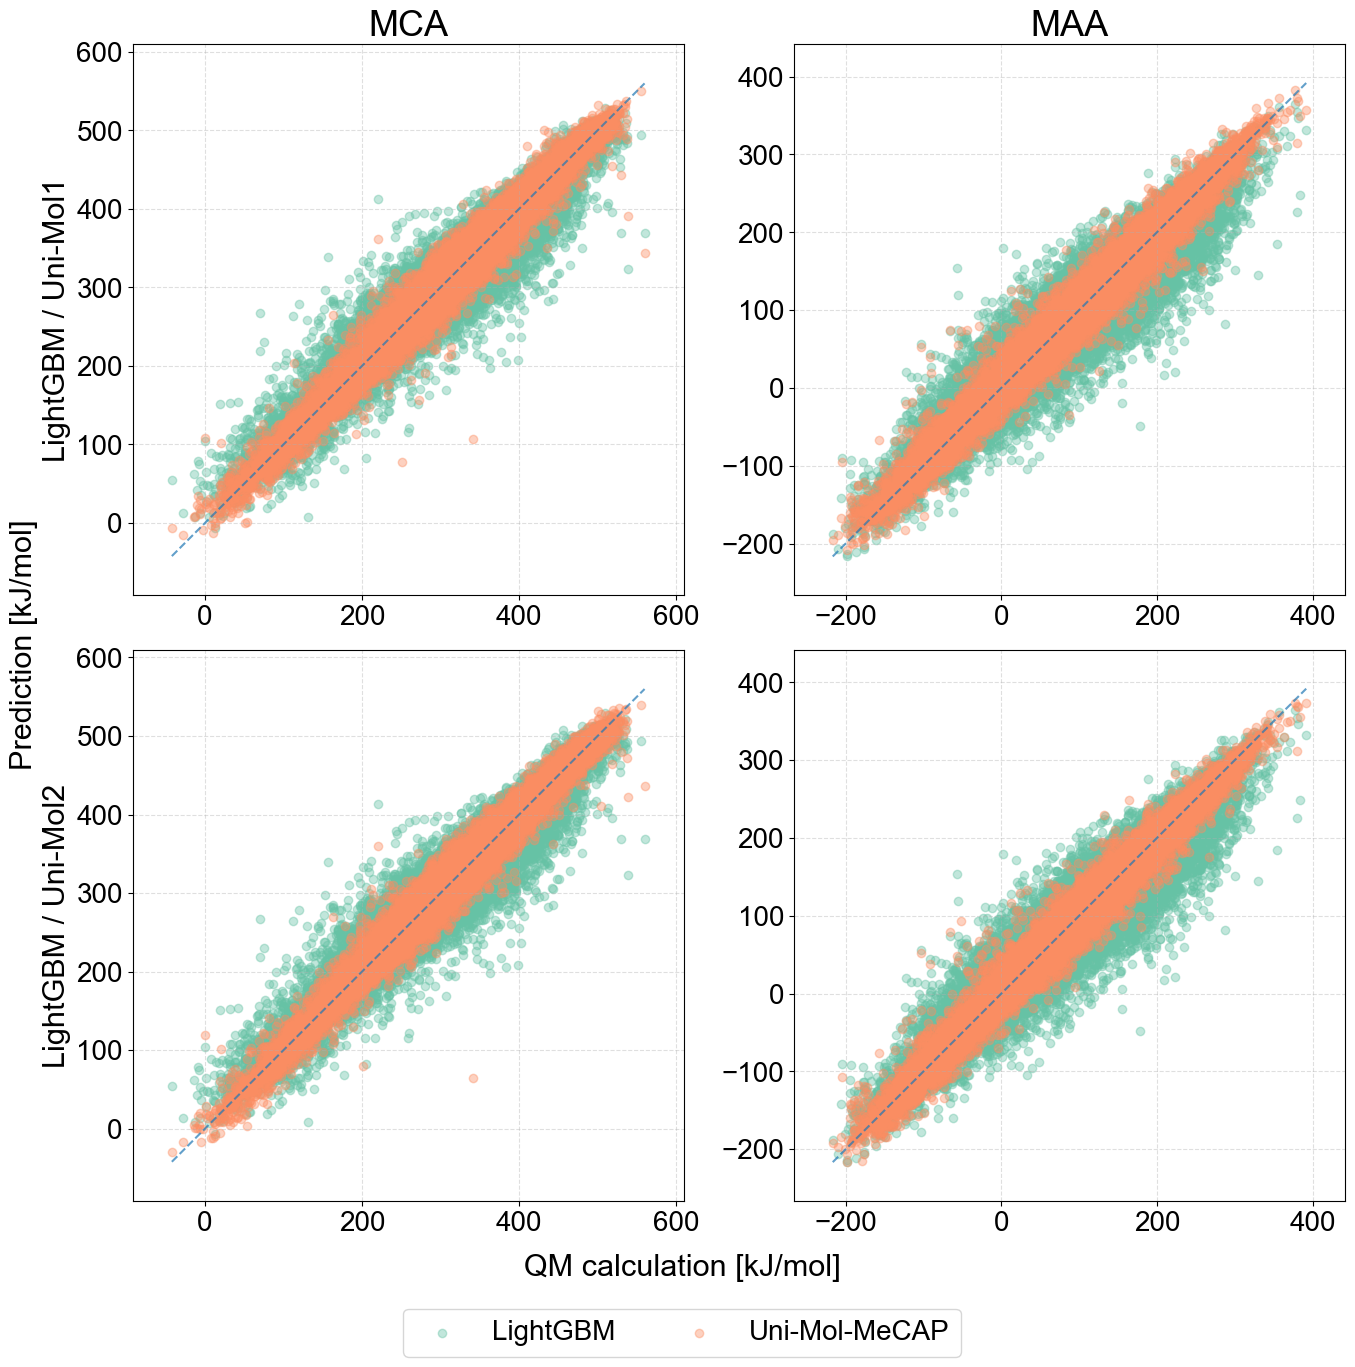

In [ ]:
import matplotlib.pyplot as plt
from mod_for_analysis import load_csv, load_pred_value, stats_and_plot

alpha = 0.4
base_font_size = 20

ticks_font_size = int(base_font_size)
title_font_size = int(base_font_size * 1.3)
label_font_size = int(base_font_size * 1.1)

ESNUEL_COLOR = '#66c2a5'
UNIMOL_COLOR = '#fc8d62'

plot, axes = plt.subplots(2, 2, figsize=(14, 13))
axes = axes.flatten()

legend_handles = {}

def make_parity_plot(task_name, ax):
    pred_target = 'MCA_values' if 'mca' in task_name else 'MAA_values'
    task_target = 'nuc' if 'mca' in task_name else 'elec'
    df = load_csv(f'./results/{task_name}/predictions.csv')
    df['esnuelML'] = load_pred_value(f'./references/esnuelML_{task_target}_predicted_values.csv')
    df_test = df[df['Set']=='Test']

    esnuel_scatter = ax.scatter(df_test[pred_target], df_test['esnuelML'], alpha=alpha, color=ESNUEL_COLOR)
    if 'LightGBM' not in legend_handles:
        # esnuel_scatter.set_alpha(1.0)
        legend_handles['LightGBM'] = esnuel_scatter

    collections_before = len(ax.collections)

    stats_and_plot(
        df_test[pred_target],
        df_test['pred'],
        ax=ax,
        title=pred_target[:3],
        x_label='QM calculation [kJ/mol]',
        y_label='',
        alpha=alpha,
        visualize_stats=False,
    )

    new_collections = [coll for coll in ax.collections[collections_before:] if coll is not esnuel_scatter]
    if new_collections:
        unimol_scatter = new_collections[0]
        unimol_scatter.set_facecolor(UNIMOL_COLOR)
        unimol_scatter.set_edgecolor(UNIMOL_COLOR)
        # unimol_scatter.set_alpha(1.0)
        if 'Uni-Mol-MeCAP' not in legend_handles:
            legend_handles['Uni-Mol-MeCAP'] = unimol_scatter

    ax.tick_params(axis='both', labelsize=ticks_font_size)
    ax.title.set_size(title_font_size)

make_parity_plot('mecap_ref_mca_layer_0', axes[0])
axes[0].set_xlabel('')
axes[0].set_ylabel('LightGBM / Uni-Mol1', fontsize=label_font_size)
axes[0].set_aspect('equal')

make_parity_plot('mecap_ref_maa_layer_0', axes[1])
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_aspect('equal')

make_parity_plot('mecap_ref_mca_v2_layer_0', axes[2])
axes[2].set_title('')
axes[2].set_xlabel('')
axes[2].set_ylabel('LightGBM / Uni-Mol2', fontsize=label_font_size)
axes[2].set_aspect('equal')

make_parity_plot('mecap_ref_maa_v2_layer_0', axes[3])
axes[3].set_title('')
axes[3].set_xlabel('')
axes[3].set_ylabel('')
axes[3].set_aspect('equal')

# plot.supxlabel('QM calculation [kJ/mol]', fontsize=label_font_size, y=0.1)
plot.supxlabel('QM calculation [kJ/mol]', fontsize=label_font_size)
plot.supylabel('Prediction [kJ/mol]', fontsize=label_font_size)

plot.tight_layout()
# plot.subplots_adjust(bottom=0.15)

legend_labels = ['LightGBM', 'Uni-Mol-MeCAP']
legend_handles_list = [legend_handles[label] for label in legend_labels if label in legend_handles]
plot.legend(
    legend_handles_list,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0),
    ncol=len(legend_handles_list),
    # frameon=False,
    fontsize=int(base_font_size),
)

plot.show()

## Visualization of compounds with large-errorred predictions by Uni-Mol1-MeCAPs

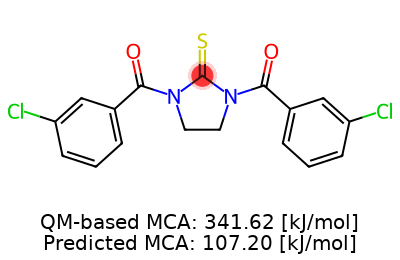

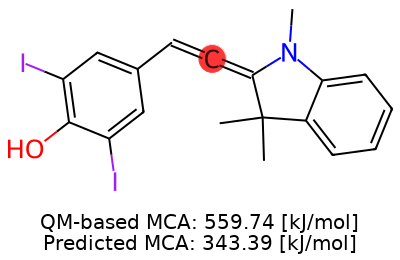

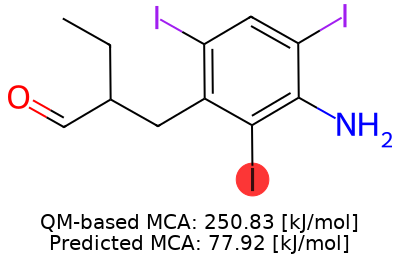

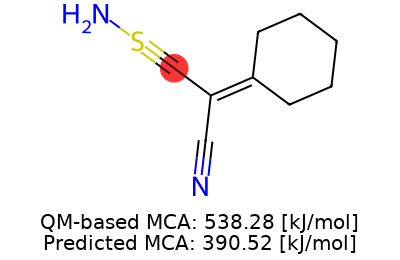

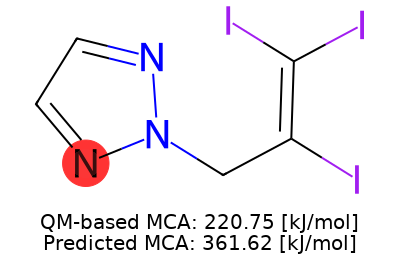

In [1]:
from mod_for_analysis import load_csv, visualize_smiles_highlight

df = load_csv('./results/mecap_ref_mca_layer_0/predictions.csv')
df = df[df['Set']=='Test']
df['abs_error'] = (df['pred'] - df['MCA_values']).abs()
df.sort_values('abs_error',ascending=False,inplace=True)

for _, row in df[['smiles','nuc_sites','MCA_values','pred','abs_error']].head().iterrows():
    fig = visualize_smiles_highlight(row['smiles'],[row['nuc_sites']],f"{row['MCA_values']:.2f}",f"{row['pred']:.2f}",highlight_thickness_px=0,image_size=(400, 200),font_size=20)
    display(fig)


## Visualization of compounds well predicted by Uni-Mol1-MeCAPs but poorly predicted by ESNUEL_ML

===== MCA =====


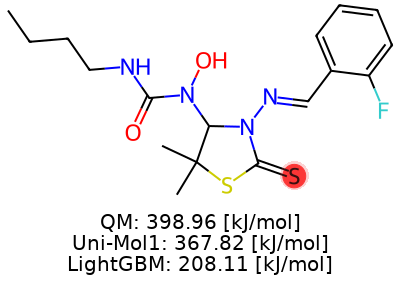

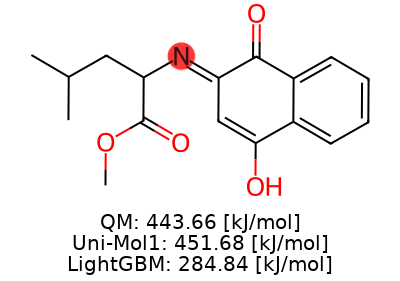



===== MAA =====


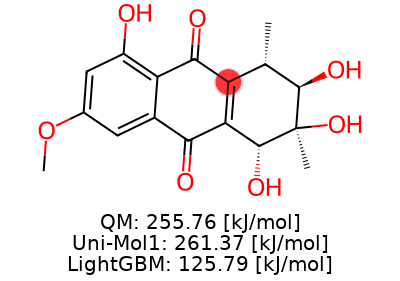

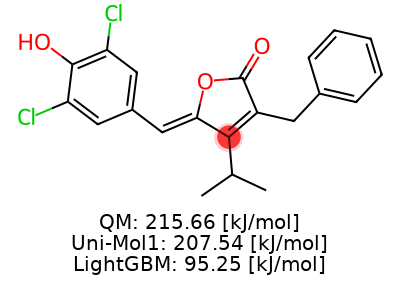

In [2]:
from rdkit import Chem
from mod_for_analysis import load_csv, load_pred_value, visualize_smiles_highlight, find_additional_nuc_sites, find_additional_elec_sites

# MCA
df_nuc = load_csv(f'./results/mecap_ref_mca_layer_0/predictions.csv')
df_nuc['esnuelML'] = load_pred_value('./references/esnuelML_nuc_predicted_values.csv')
df_nuc = df_nuc[df_nuc['Set']=='Test'].copy()
nuc_smiles_to_sites = {smi: find_additional_nuc_sites(Chem.MolFromSmiles(smi)) for smi in df_nuc['smiles'].unique()}
df_nuc['refined_nuc_names'] = df_nuc.apply(lambda row: nuc_smiles_to_sites[row['smiles']][1][nuc_smiles_to_sites[row['smiles']][0].index(row['nuc_sites'])] if row['nuc_sites'] in nuc_smiles_to_sites[row['smiles']][0] else None, axis=1)
df_nuc.dropna(subset='refined_nuc_names',inplace=True)
df_nuc['unimol_error'] = (df_nuc['MCA_values'] - df_nuc['pred']).abs()
df_nuc['esnuel_error'] = (df_nuc['MCA_values'] - df_nuc['esnuelML']).abs()
df_nuc['error_diff']   = df_nuc['unimol_error'] - df_nuc['esnuel_error']
df_nuc.sort_values('error_diff',inplace=True)

print("===== MCA =====")
for _, row in df_nuc[['smiles','nuc_sites','MCA_values','pred','esnuelML']].head(2).iterrows():
    fig = visualize_smiles_highlight(row['smiles'],[row['nuc_sites']],f"{row['MCA_values']:.2f}",f"{row['pred']:.2f}",
                                     caption_fmt="QM: {} [kJ/mol]\nUni-Mol1: {} [kJ/mol]",
                                     caption_extra={"LightGBM": f"{row['esnuelML']:.2f} [kJ/mol]"},
                                    #  highlight_color=(246, 207, 211, 100),
                                     highlight_thickness_px=0,
                                     image_size=(400, 200), font_size=20)
    display(fig)
print("\n")

# MAA
df_elec = load_csv(f'./results/mecap_ref_maa_layer_0/predictions.csv')
df_elec['esnuelML'] = load_pred_value('./references/esnuelML_elec_predicted_values.csv')
df_elec = df_elec[df_elec['Set']=='Test'].copy()
elec_smiles_to_sites = {smi: find_additional_elec_sites(Chem.MolFromSmiles(smi)) for smi in df_elec['smiles'].unique()}
df_elec['refined_elec_names'] = df_elec.apply(lambda row: elec_smiles_to_sites[row['smiles']][1][elec_smiles_to_sites[row['smiles']][0].index(row['elec_sites'])] if row['elec_sites'] in elec_smiles_to_sites[row['smiles']][0] else None, axis=1)
df_elec.dropna(subset='refined_elec_names',inplace=True)
df_elec['unimol_error'] = (df_elec['MAA_values'] - df_elec['pred']).abs()
df_elec['esnuel_error'] = (df_elec['MAA_values'] - df_elec['esnuelML']).abs()
df_elec['error_diff']   = df_elec['unimol_error'] - df_elec['esnuel_error']
df_elec.sort_values('error_diff',inplace=True)

print("===== MAA =====")
for _, row in df_elec[['smiles','elec_sites','MAA_values','pred','esnuelML']].head(2).iterrows():
    fig = visualize_smiles_highlight(row['smiles'],[row['elec_sites']],f"{row['MAA_values']:.2f}",f"{row['pred']:.2f}",
                                     caption_fmt="QM: {} [kJ/mol]\nUni-Mol1: {} [kJ/mol]",
                                     caption_extra={"LightGBM": f"{row['esnuelML']:.2f} [kJ/mol]"},
                                    #  highlight_color=(246, 207, 211, 254),
                                     highlight_thickness_px=0,
                                     image_size=(400, 200), font_size=20)
    display(fig)

df_nuc.to_csv(f'./results/mecap_ref_mca_layer_0/predictions_test_with_additional_annotations.csv')
df_elec.to_csv(f'./results/mecap_ref_maa_layer_0/predictions_test_with_additional_annotations.csv')


## Interpretation

2026-03-11 16:47:16 | core_modules/model.py | 614 | INFO | Uni-Mol Tools | Loading checkpoint (strict) into unimolv1: ./results/mecap_ref_mca_layer_0/best_model.pt
2026-03-11 16:47:16 | core_modules/model.py | 614 | INFO | Uni-Mol Tools | Loading checkpoint (strict) into unimolv1: ./results/mecap_ref_maa_layer_0/best_model.pt


===== MCA =====


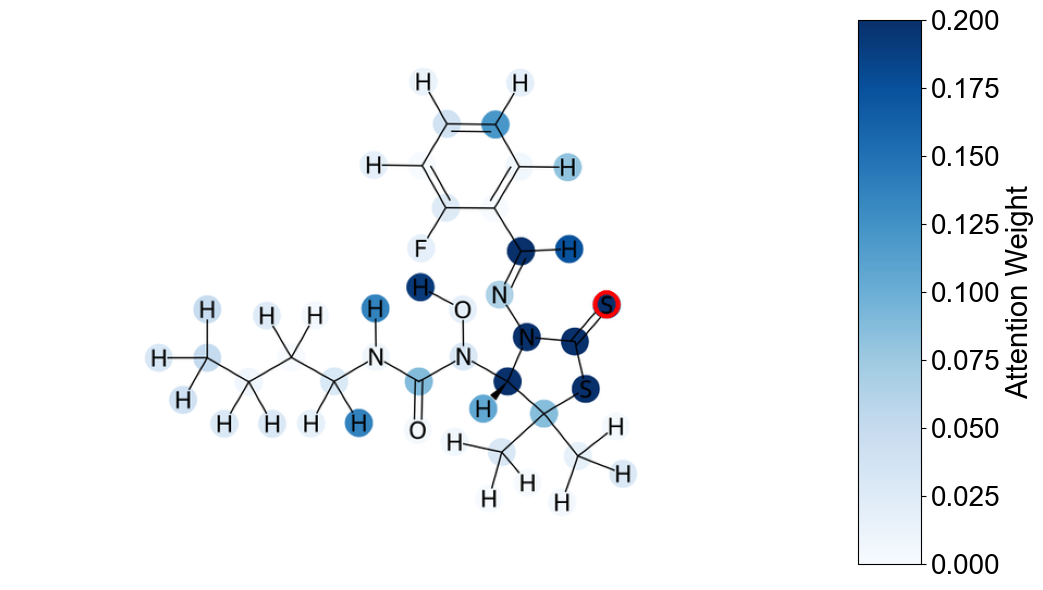

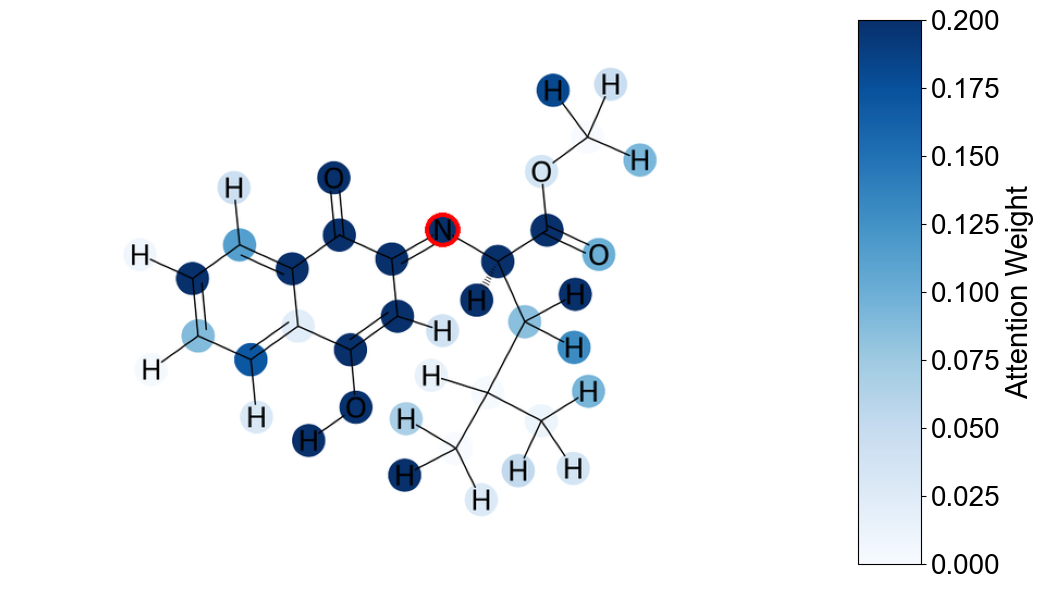



===== MAA =====


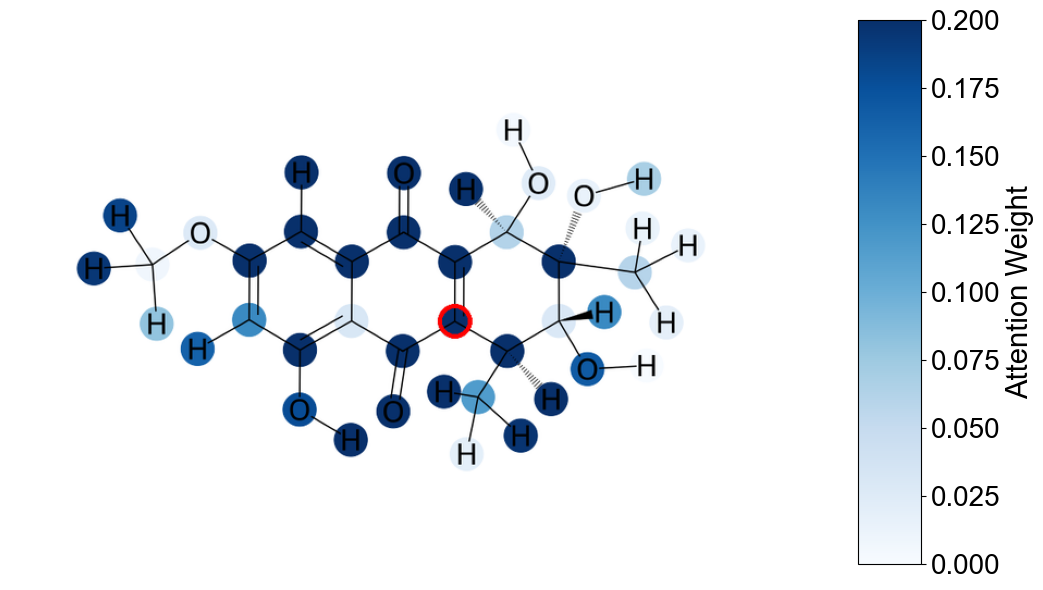

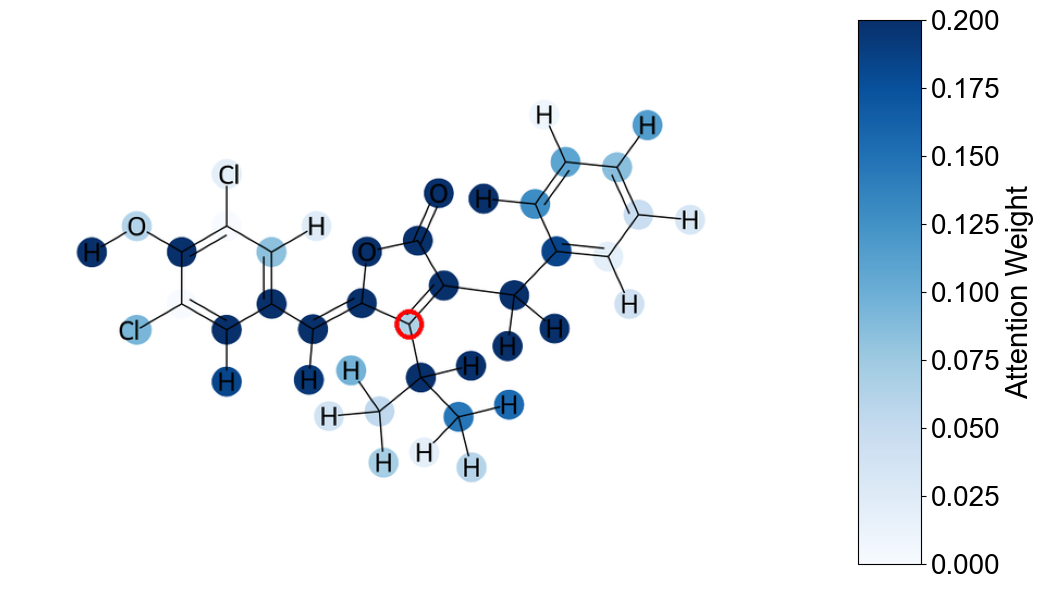

In [3]:
import os, sys
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["font.family"] = "Arial"

base_dir = os.path.abspath('../src')
if base_dir not in sys.path:
    sys.path.append(base_dir)

from visualize_attention_map import compute_and_visualize_attention_maps
from core_modules.model import build_model_from_checkpoint

mstate_mca, model_mca, device_ = build_model_from_checkpoint('./results/mecap_ref_mca_layer_0/best_model.pt')
mstate_maa, model_maa, device_ = build_model_from_checkpoint('./results/mecap_ref_maa_layer_0/best_model.pt')

# MCA
print("===== MCA =====")
df_nuc = pd.read_csv(f'./results/mecap_ref_mca_layer_0/predictions_test_with_additional_annotations.csv',index_col=0)
for _, row in df_nuc[['name','smiles','nuc_sites','MCA_values','pred','esnuelML']].head(2).iterrows():
    fig = compute_and_visualize_attention_maps(
        f"./results/confs_from_smiles_rdkit/{row['name']}.sdf",
        int(row['nuc_sites']),
        model_mca,
        True,
        row['MCA_values'],
        row['pred'],
        img_size = (700, 500),
        show_title = False,
        font_size = 24,
        cmap = 'Blues' # cmap
        )
    display(fig)
    plt.close()
print("\n")

# MAA
print("===== MAA =====")
df_elec = pd.read_csv(f'./results/mecap_ref_maa_layer_0/predictions_test_with_additional_annotations.csv',index_col=0)
for _, row in df_elec[['name','smiles','elec_sites','MAA_values','pred','esnuelML']].head(2).iterrows():
    fig = compute_and_visualize_attention_maps(
        f"./results/confs_from_smiles_rdkit/{row['name']}.sdf",
        int(row['elec_sites']),
        model_maa,
        True,
        row['MAA_values'],
        row['pred'],
        img_size = (700, 500),
        show_title = False,
        font_size = 24,
        cmap = 'Blues' # cmap
        )
    display(fig)
    plt.close()
print("\n")


# Analysis on "rare" substructure -focusing on thiourea and allene-

In [ ]:
# Count number of "rare" substructures

import pandas as pd
from tqdm import tqdm
from rdkit import Chem
from mod_for_analysis import thu_aln_smirks_dict, element_dict, substructure_match

queries = {key: Chem.MolFromSmarts(sma) for key, sma in thu_aln_smirks_dict.items()}

df  = pd.read_csv('./references/QMdata4ML/df_nuc_x_with_name_fold.csv',index_col=0)

df_nuc_train  = df[df['Set_fold1']=='train']

count = {name: 0 for name in queries.keys()}

for smi, gdf in tqdm(df_nuc_train.groupby('smiles'),desc='Substructure Match',total=len(df_nuc_train['smiles'].unique())):
    idxs = [int(idx) for idx in gdf['nuc_sites']]
    for name, query in queries.items():
        elem = element_dict[name]
        subs = substructure_match(Chem.MolFromSmiles(smi),query)
        for sub in subs:
            if int(sub[elem]) in idxs:
                count[name] = count[name] + 1

print(count)

Substructure Match: 100%|██████████| 47792/47792 [00:25<00:00, 1847.99it/s]

{'thiourea': 8, 'allene': 65}


# Analysis on Bemis-Murcko-scaffold-based split

In [1]:
'''Statistical table for Bemis-Murcko-scaffold-based split'''
import pandas as pd
from mod_for_analysis import load_csv, calculate_stats, extract_best_epoch

mca_dict, maa_dict = {}, {}

# MCA
be_ = extract_best_epoch(f'./results/mecap_scaf_mca_layer_0/train.log')
df = load_csv(f'./results/mecap_scaf_mca_layer_0/predictions.csv')
df_test = df[df['Set_scaffold']=='test']
r, r2, rmse = calculate_stats(df_test['MCA_values'],df_test['pred'])
mca_dict[f'UniMol1_MCA'] = {
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}

# MAA
be_ = extract_best_epoch(f'./results/mecap_scaf_maa_layer_0/train.log')
df = load_csv(f'./results/mecap_scaf_maa_layer_0/predictions.csv')
df_test = df[df['Set_scaffold']=='test']
r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['pred'])
maa_dict[f'UniMol1_MAA'] = {
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}


print('===MCA===')
display(pd.DataFrame(mca_dict).T)

print('===MAA===')
display(pd.DataFrame(maa_dict).T)

===MCA===


,best_epoch,r,r2,rmse
UniMol1_MCA,49.0,0.987887,0.975083,11.51688


===MAA===


,best_epoch,r,r2,rmse
UniMol1_MAA,44.0,0.983143,0.966054,13.228233


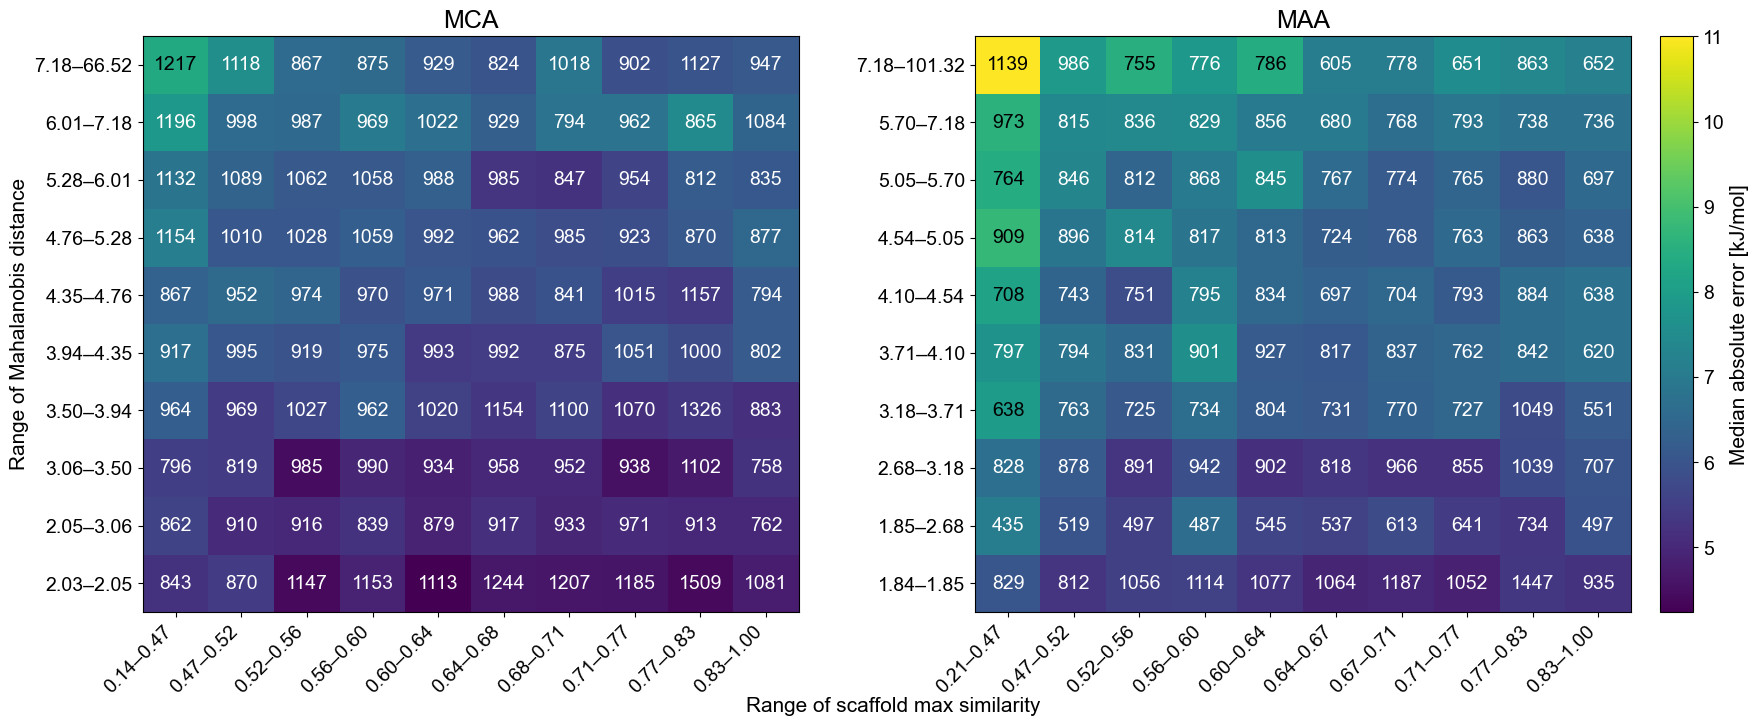

In [9]:
"""Correlation of distance and prediction error"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mod_for_analysis import load_csv

# 2D-binning setting
N_BINS_SIM = 10
N_BINS_MDIST = 10
MIN_CELL_N = 200
HEATMAP_CMAP = "viridis"
MASK_COLOR = "lightgray"

base_font_size = 14
ticks_font_size = int(base_font_size)
title_font_size = int(base_font_size * 1.3)
label_font_size = int(base_font_size * 1.1)

plt.rcParams["font.family"] = "Arial"


def _trimmed_mean(x, trim=0.1):
    if len(x) == 0:
        return np.nan
    lo, hi = x.quantile(trim), x.quantile(1 - trim)
    return x[(x >= lo) & (x <= hi)].mean()


def _format_interval_labels(interval_index, fmt="{:.3f}"):
    """
    Convert pandas IntervalIndex/Categorical interval categories to readable strings.
    Example: (0.123, 0.456] -> "0.123–0.456"
    """
    labels = []
    for iv in interval_index:
        if pd.isna(iv):
            labels.append("")
            continue
        # iv is a pandas Interval
        labels.append(f"{fmt.format(iv.left)}–{fmt.format(iv.right)}")
    return labels


def summarize_2d_error(
    df,
    true_col,
    pred_col="pred",
    sim_col="ScafMaxSim",
    mdist_col="MDist",
    n_bins_sim=N_BINS_SIM,
    n_bins_mdist=N_BINS_MDIST,
    min_cell_n=MIN_CELL_N,
    use_trimmed_mean=False,
    trim=0.1,
):
    d = df[[true_col, pred_col, sim_col, mdist_col]].dropna().copy()
    d["abs_error"] = (d[pred_col] - d[true_col]).abs()

    # qcut returns categorical intervals
    d["sim_bin"] = pd.qcut(d[sim_col], q=n_bins_sim, duplicates="drop")
    d["mdist_bin"] = pd.qcut(d[mdist_col], q=n_bins_mdist, duplicates="drop")

    agg_fn = (lambda s: _trimmed_mean(s, trim=trim)) if use_trimmed_mean else "median"

    g = (
        d.groupby(["sim_bin", "mdist_bin"], observed=True)
        .agg(
            error=("abs_error", agg_fn),
            n=("abs_error", "size"),
        )
        .reset_index()
    )

    heat_error = g.pivot(index="mdist_bin", columns="sim_bin", values="error")
    heat_n = g.pivot(index="mdist_bin", columns="sim_bin", values="n").fillna(0)

    # mask sparse cells
    heat_error = heat_error.mask(heat_n < min_cell_n)
    return g, heat_error, heat_n


def plot_2d_error_heatmap(
    ax,
    heat_error,
    heat_n,
    title,
    cmap=HEATMAP_CMAP,
    vmin=None,
    vmax=None,
    tick_fmt="{:.3f}",
    cell_fontsize=None,
):
    m = np.ma.masked_invalid(heat_error.values)
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(MASK_COLOR)

    im = ax.imshow(m, aspect="auto", origin="lower", cmap=cmap_obj, vmin=vmin, vmax=vmax)

    # Use interval ranges as tick labels
    x_intervals = list(heat_error.columns)
    y_intervals = list(heat_error.index)
    x_labels = _format_interval_labels(x_intervals, fmt=tick_fmt)
    y_labels = _format_interval_labels(y_intervals, fmt=tick_fmt)

    ax.set_xticks(np.arange(heat_error.shape[1]))
    ax.set_yticks(np.arange(heat_error.shape[0]))
    ax.set_xticklabels(x_labels, rotation=45, ha="right")
    ax.set_yticklabels(y_labels)

    ax.tick_params(axis="both", labelsize=ticks_font_size)
    ax.yaxis.tick_left()
    ax.tick_params(axis="y", left=True, labelleft=True, right=False, labelright=False, pad=4)
    ax.set_xlabel("")
    ax.set_ylabel("Range of Mahalanobis distance", fontsize=label_font_size)
    ax.set_title(title, fontsize=title_font_size)

    # Cell count annotation (no 'n='), bigger font, color adapted to background
    if cell_fontsize is None:
        cell_fontsize = ticks_font_size  # bigger than before

    # For text color decision, normalize by vmin/vmax if available
    if vmin is None or vmax is None or not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        # Fallback: always white text
        def _text_color(_val):
            return "white"
    else:
        def _text_color(val):
            # Use white on darker colors, black on brighter colors
            # Threshold at mid-point in normalized space
            t = (val - vmin) / (vmax - vmin)
            return "white" if t < 0.55 else "black"

    for i in range(heat_n.shape[0]):
        for j in range(heat_n.shape[1]):
            n_ij = int(heat_n.iloc[i, j]) if not np.isnan(heat_n.iloc[i, j]) else 0
            val = heat_error.iloc[i, j]
            if np.isnan(val):
                # Masked cell: use dark text on gray background
                color = "black"
            else:
                color = _text_color(float(val))
            ax.text(j, i, f"{n_ij}", ha="center", va="center", fontsize=cell_fontsize, color=color)

    return im


# ---- Load and summarize ----
# MCA
df = load_csv("./results/mecap_scaf_mca_layer_0/predictions.csv")
df_test_mca = df[df["Set_scaffold"] == "test"].copy()
mca_g, mca_heat_error, mca_heat_n = summarize_2d_error(df_test_mca, true_col="MCA_values")

# MAA
df = load_csv("./results/mecap_scaf_maa_layer_0/predictions.csv")
df_test_maa = df[df["Set_scaffold"] == "test"].copy()
maa_g, maa_heat_error, maa_heat_n = summarize_2d_error(df_test_maa, true_col="MAA_values")

# Shared color range (robust option: use percentiles if outliers dominate)
vals = np.concatenate([mca_heat_error.to_numpy().ravel(), maa_heat_error.to_numpy().ravel()])
vals = vals[np.isfinite(vals)]
shared_vmin, shared_vmax = float(vals.min()), float(vals.max())
# If you want robust scaling, uncomment:
# shared_vmin, shared_vmax = np.quantile(vals, [0.02, 0.98])

# ---- Plot with dedicated colorbar axis (no overlap) ----
fig = plt.figure(figsize=(20, 8))
fig.subplots_adjust(bottom=0.16)
gs = fig.add_gridspec(1, 4, width_ratios=[1, 0.18, 1, 0.05], wspace=0.08)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 2])
cax = fig.add_subplot(gs[0, 3])

im0 = plot_2d_error_heatmap(
    ax0, mca_heat_error, mca_heat_n, "MCA",
    vmin=shared_vmin, vmax=shared_vmax,
    tick_fmt="{:.2f}",
    cell_fontsize=ticks_font_size,  # bigger text in cells
)
im1 = plot_2d_error_heatmap(
    ax1, maa_heat_error, maa_heat_n, "MAA",
    vmin=shared_vmin, vmax=shared_vmax,
    tick_fmt="{:.2f}",
    cell_fontsize=ticks_font_size,
)

fig.supxlabel("Range of scaffold max similarity", fontsize=label_font_size, y=0.03)

# Keep independent MDist bins on each panel while showing tick labels on the left side
ax1.set_ylabel("")
ax1.yaxis.set_label_position("left")
ax1.yaxis.tick_left()

# Colorbar in separate axis
cbar = fig.colorbar(im1, cax=cax)
cbar.set_label("Median absolute error [kJ/mol]", fontsize=label_font_size)
cbar.ax.tick_params(labelsize=ticks_font_size)

plt.show()

# Conformer RMSD check (QM calculation input, RMSD-max input)

<>:37: SyntaxWarning: invalid escape sequence '\A'
<>:37: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_3521397/1193567067.py:37: SyntaxWarning: invalid escape sequence '\A'
  ax.set_xlabel("RMSD [$\AA$]")


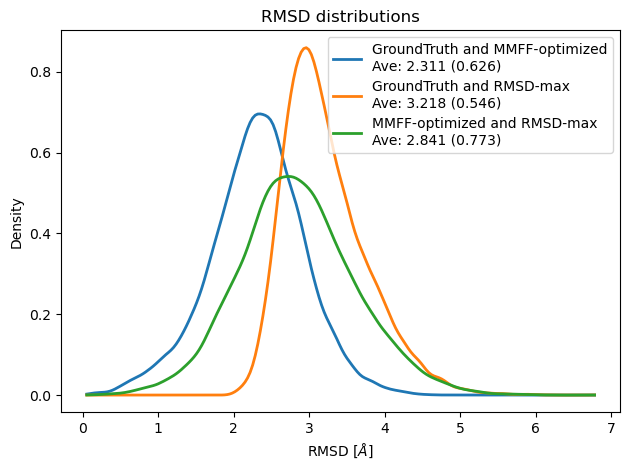

In [ ]:
import collections, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

convert_dir_name_to_met = {
    'confs_orca': 'GroundTruth',
    'confs_from_smiles_rdkit': 'MMFF-optimized',
    'rmsd_max': 'RMSD-max',
    }

df = pd.read_csv('./results/optimizing/conformation_rmsd.csv',index_col=None)
df['combi'] = df.apply(lambda row: convert_dir_name_to_met[os.path.basename(row['dir1'])] + ' and ' + convert_dir_name_to_met[os.path.basename(row['dir2'])], axis=1)

fig, ax1 = plt.subplots()

x_min, x_max = df['rmsd'].min(), df['rmsd'].max()
x_grid = np.linspace(x_min, x_max, 200)

for name, gdf in df.groupby('combi'):
    values = gdf['rmsd'].dropna()

    counter = collections.Counter(values)
    # for v, cnt in sorted(counter.items()):
    #     print(f"{v}: {cnt}")


    # ax.hist(values_arr, bins="auto", density=True, alpha=0.6, edgecolor="black")

    kde = gaussian_kde(values)

    y_kde_gth_mmff = kde(x_grid)
    
    ax1.plot(x_grid, y_kde_gth_mmff, linewidth=2, label=f'{name}\nAve: {values.mean():.3f} ({values.std():.3f})')

ax1.set_xlabel("RMSD [$\AA$]")
ax1.set_ylabel("Density")
ax1.set_title("RMSD distributions")
ax1.legend()

plt.tight_layout()
plt.show()


# Predict (xTB-optimized) - Predict (RMSD-max) plot

In [ ]:
'''Statistical table for different conformations'''
import pandas as pd
from mod_for_analysis import load_csv, calculate_stats, extract_best_epoch

mca_dict, maa_dict = {}, {}

## Ground truth
# MCA
be_ = extract_best_epoch(f'./results/different_conformation/mecap_ref_mca_gth_layer_0/train.log')
df = load_csv(f'./results/different_conformation/mecap_ref_mca_gth_layer_0/predictions.csv').dropna(subset=['pred'])
df_test = df[df['Set']=='Test']
r, r2, rmse = calculate_stats(df_test['MCA_values'],df_test['pred'])
mca_dict[f'UniMol1_MCA_GroundTruth'] = {
    'train': len(df[df['Set_fold1']=='train']),
    'valid': len(df[df['Set_fold1']=='val']),
    'test': len(df[df['Set_fold1']=='test']),
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}

# MAA
be_ = extract_best_epoch(f'./results/different_conformation/mecap_ref_maa_gth_layer_0/train.log')
df = load_csv(f'./results/different_conformation/mecap_ref_maa_gth_layer_0/predictions.csv').dropna(subset=['pred'])
df_test = df[df['Set']=='Test']
r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['pred'])
maa_dict[f'UniMol1_MAA_GroundTruth'] = {
    'train': len(df[df['Set_fold1']=='train']),
    'valid': len(df[df['Set_fold1']=='val']),
    'test': len(df[df['Set_fold1']=='test']),
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}

## Optimized by xTB (Uni-Mol type conformer generation)
# MCA
be_ = extract_best_epoch(f'./results/different_conformation/mecap_ref_mca_mmff_layer_0/train.log')
df = load_csv(f'./results/different_conformation/mecap_ref_mca_mmff_layer_0/predictions.csv').dropna(subset=['pred'])
df_test = df[df['Set']=='Test']
r, r2, rmse = calculate_stats(df_test['MCA_values'],df_test['pred'])
mca_dict[f'UniMol1_MCA_mmff'] = {
    'train': len(df[df['Set_fold1']=='train']),
    'valid': len(df[df['Set_fold1']=='val']),
    'test': len(df[df['Set_fold1']=='test']),
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}

# MAA
be_ = extract_best_epoch(f'./results/different_conformation/mecap_ref_maa_mmff_layer_0/train.log')
df = load_csv(f'./results/different_conformation/mecap_ref_maa_mmff_layer_0/predictions.csv').dropna(subset=['pred'])
df_test = df[df['Set']=='Test']
r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['pred'])
maa_dict[f'UniMol1_MAA_mmff'] = {
    'train': len(df[df['Set_fold1']=='train']),
    'valid': len(df[df['Set_fold1']=='val']),
    'test': len(df[df['Set_fold1']=='test']),
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}

## ""Far"" conformation from xTB-optimized conf
# MCA
be_ = extract_best_epoch(f'./results/different_conformation/mecap_ref_mca_rmsd_layer_0/train.log')
df = load_csv(f'./results/different_conformation/mecap_ref_mca_rmsd_layer_0/predictions.csv').dropna(subset=['pred'])
df_test = df[df['Set']=='Test']
r, r2, rmse = calculate_stats(df_test['MCA_values'],df_test['pred'])
mca_dict[f'UniMol1_MCA_rmsd'] = {
    'train': len(df[df['Set_fold1']=='train']),
    'valid': len(df[df['Set_fold1']=='val']),
    'test': len(df[df['Set_fold1']=='test']),
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}

# MAA
be_ = extract_best_epoch(f'./results/different_conformation/mecap_ref_maa_rmsd_layer_0/train.log')
df = load_csv(f'./results/different_conformation/mecap_ref_maa_rmsd_layer_0/predictions.csv').dropna(subset=['pred'])
df_test = df[df['Set']=='Test']
r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['pred'])
maa_dict[f'UniMol1_MAA_rmsd'] = {
    'train': len(df[df['Set_fold1']=='train']),
    'valid': len(df[df['Set_fold1']=='val']),
    'test': len(df[df['Set_fold1']=='test']),
    'best_epoch': be_,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}

## ""Far"" conformation from xTB-optimized conf (input to xTB-optimized model)
# MAA
df = load_csv(f'./results/different_conformation/mecap_ref_maa_gth_predict_by_rmsd_layer_0/predictions.csv').dropna(subset=['pred'])
df_test = df[df['Set']=='Test']
r, r2, rmse = calculate_stats(df_test['MAA_values'],df_test['pred'])
maa_dict[f'UniMol1_MAA_xTB_from_rmsd'] = {
    'train': len(df[df['Set_fold1']=='train']),
    'valid': len(df[df['Set_fold1']=='val']),
    'test': len(df[df['Set_fold1']=='test']),
    'best_epoch': None,
    'r2': r2,
    'r': r,
    'rmse': rmse,
}


print('===MCA===')
display(pd.DataFrame(mca_dict).T)

print('===MAA===')
display(pd.DataFrame(maa_dict).T)

===MCA===


,train,valid,test,best_epoch,r2,r,rmse
UniMol1_MCA_GroundTruth,212689.0,53360.0,46995.0,48.0,0.979244,0.989821,10.581071
UniMol1_MCA_mmff,212689.0,53360.0,46995.0,50.0,0.977607,0.989424,10.990522
UniMol1_MCA_rmsd,212689.0,53360.0,46995.0,50.0,0.977027,0.989029,11.131946


===MAA===


,train,valid,test,best_epoch,r2,r,rmse
UniMol1_MAA_GroundTruth,173350.0,43367.0,38428.0,50.0,0.971020,0.986047,11.957508
UniMol1_MAA_mmff,173350.0,43367.0,38428.0,44.0,0.970947,0.985757,11.972710
UniMol1_MAA_rmsd,173350.0,43367.0,38428.0,50.0,0.969725,0.985395,12.221881
UniMol1_MAA_xTB_from_rmsd,173350.0,43367.0,38428.0,NaN,0.945514,0.972471,16.395943


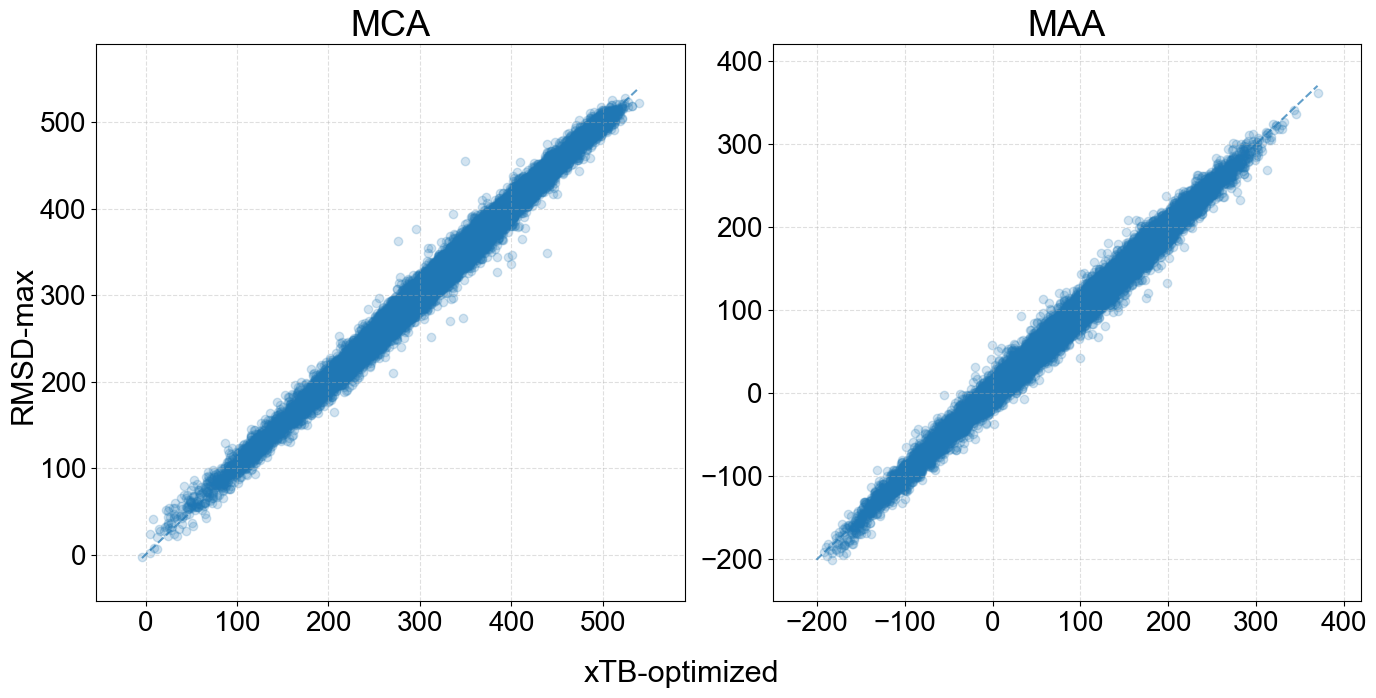

In [ ]:
import matplotlib.pyplot as plt
from mod_for_analysis import load_csv, stats_and_plot

alpha = 0.2
base_font_size = 20

ticks_font_size = int(base_font_size)
title_font_size = int(base_font_size * 1.3)
label_font_size = int(base_font_size * 1.1)

# Basic plot setting
plot, axes = plt.subplots(1, 2, figsize=(14,7))
axes = axes.flatten()

def make_parity_plot(task_1, task_2, ax):
    df = load_csv(f'./results/{task_1}/predictions.csv')
    pred_task1 = df[df['Set']=='Test']['pred']
    df = load_csv(f'./results/{task_2}/predictions.csv')
    pred_task2 = df[df['Set']=='Test']['pred']
    stats_and_plot(pred_task1,pred_task2,
                ax=ax,
                title='MCA' if 'mca' in task_1.lower() else 'MAA',
                x_label='',
                y_label='',
                alpha=alpha,
                visualize_stats=False)
    # enlarge axis-label font size for axes[0]
    ax.tick_params(axis='both', labelsize=ticks_font_size)  # larger tick labels
    ax.title.set_size(title_font_size)

## Uni-Mol1
# MCA
make_parity_plot('mecap_ref_mca_esnuel_orca_layer_0', 'mecap_ref_mca_rmsd_layer_0', axes[0])
axes[0].set_xlabel(''); axes[0].set_ylabel('')

# MAA
make_parity_plot('mecap_ref_maa_esnuel_orca_layer_0', 'mecap_ref_maa_rmsd_layer_0', axes[1])
axes[1].set_xlabel(''); axes[1].set_ylabel('')

plot.supxlabel('xTB-optimized',fontsize=label_font_size)
plot.supylabel('RMSD-max',fontsize=label_font_size)

plot.tight_layout()

plot.show()

plot.tight_layout()

plot.show()

# Analysis over functional groups

In [ ]:
import pandas as pd
from mod_for_analysis import load_csv, compute_local_pairwise_distance_change

def _build_wide_df(which: str) -> pd.DataFrame:
    """Load base prediction + additional predictions and merge into a wide table."""
    base = load_csv(f'./results/mecap_ref_{which}_layer_0/predictions.csv').copy()
    base = base.rename(columns={"pred": "mmff"})

    xtb = load_csv(f'./results/mecap_ref_{which}_esnuel_orca_layer_0/predictions.csv')[["pred"]].rename(
        columns={"pred": "esnuel_orca"}
    )
    rmsd = load_csv(f'./results/mecap_ref_{which}_rmsd_layer_0/predictions.csv')[["pred"]].rename(
        columns={"pred": "rmsd"}
    )

    wide = pd.concat([base, xtb, rmsd], axis=1)
    return wide

_compare = {
    'MMFF': './results/confs_from_smiles_rdkit',
    'RMSD_max': './results/rmsd_max',
    }

res_dfs = {}

for met in ('mca','maa',):
    atom_index_col = 'nuc_sites' if met=='mca' else 'elec_sites'
    res_dfs[met] = _build_wide_df(met)
    for _confname, _dir in _compare.items():
        res_dfs[met] = pd.concat([
            res_dfs[met],
            compute_local_pairwise_distance_change(
                res_dfs[met][['name',atom_index_col]],
                dir_a='./references/confs_orca',
                dir_b=_dir,
                radius=2,
                atom_index_col=atom_index_col,
                removeHs=True,
                result_col=f'D (xTB-{_confname})',
            )[[f'D (xTB-{_confname})']]
        ],axis=1)
    res_dfs[met].to_csv(f'./results/mecap_ref_{met}_predictions_by_different_confs.csv')

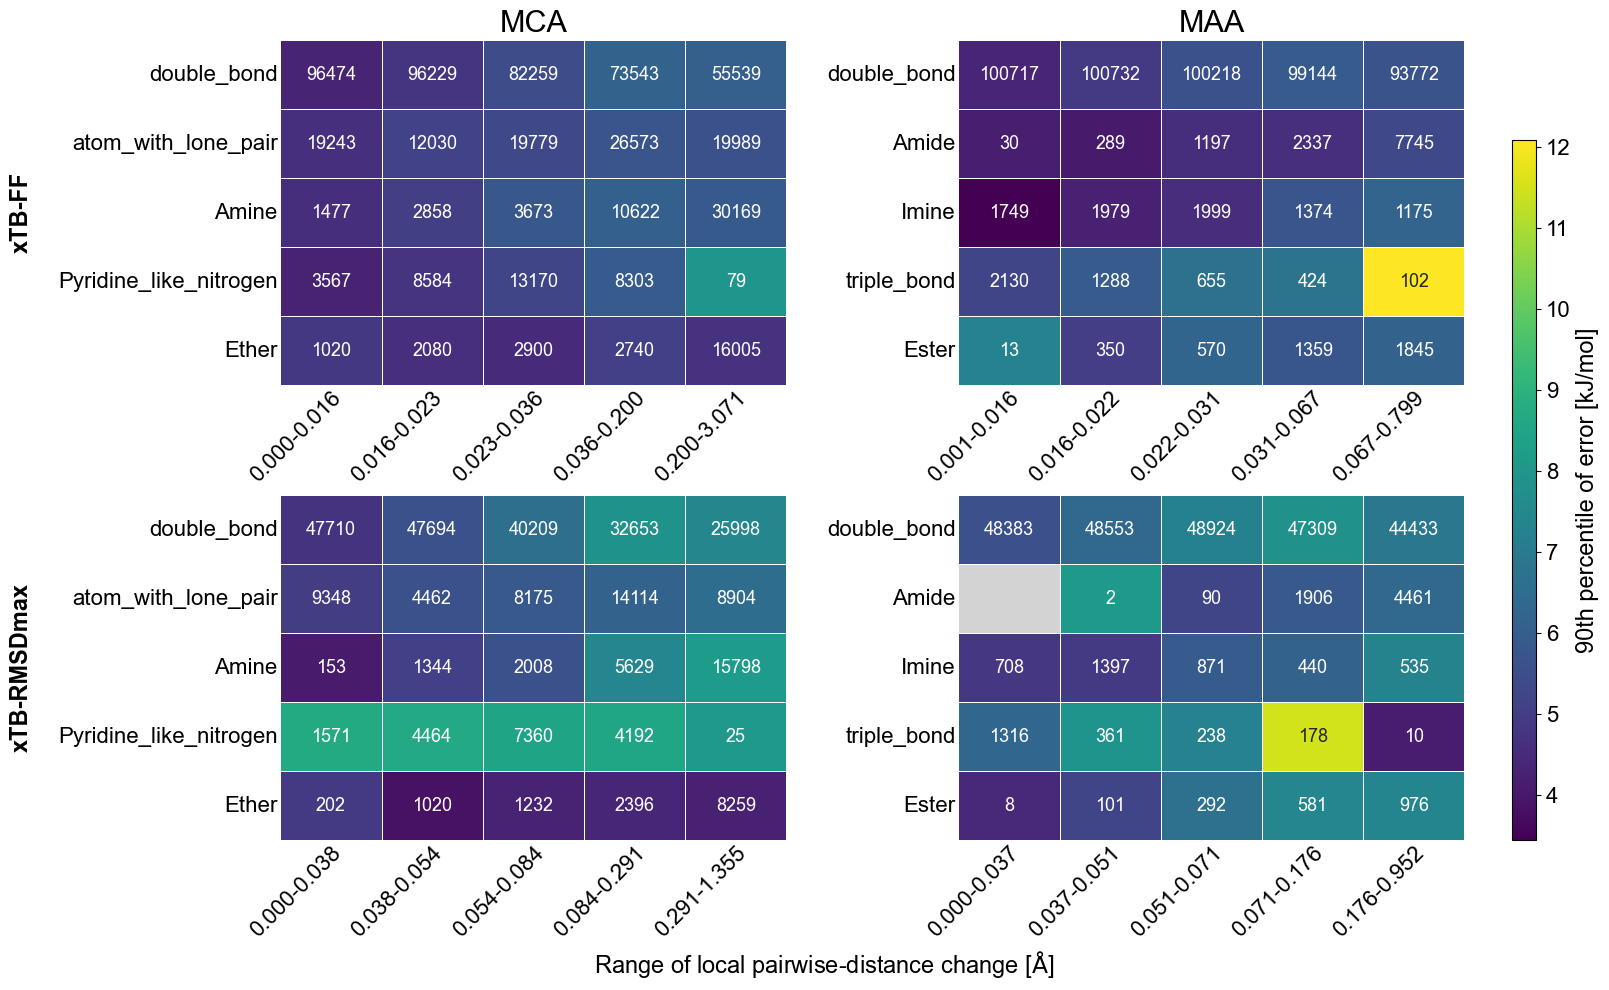

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mod_for_analysis import load_csv

plt.rcParams["font.family"] = "Arial"

UNIMOL_COLOR = '#5F8FFF'

BASE_FONT_SIZE = 16
TICKS_FONT_SIZE = int(BASE_FONT_SIZE)
TITLE_FONT_SIZE = int(BASE_FONT_SIZE * 1.4)
LABEL_FONT_SIZE = int(BASE_FONT_SIZE * 1.1)
SUBTITLE_FONT_SIZE = int(BASE_FONT_SIZE * 1.05)

N_BINS = 5
PERCENTILE = 0.50
TOP_K = 5

df_nuc = load_csv('./results/mecap_ref_mca_predictions_by_different_confs.csv').copy()
df_elec = load_csv('./results/mecap_ref_maa_predictions_by_different_confs.csv').copy()

def _prepare_abs_error(df):
    true_val = 'MCA_values' if 'MCA_values' in df.columns else 'MAA_values'
    df = df.copy()
    df['abs_error_mmff'] = (df['mmff'] - df[true_val]).abs() - (df['esnuel_orca'] - df[true_val]).abs()
    df['abs_error_rmsd'] = (df['rmsd'] - df[true_val]).abs() - (df['esnuel_orca'] - df[true_val]).abs()
    return df

def _interval_label(interval):
    return f'{abs(interval.left):.3f}-{abs(interval.right):.3f}'

def _summarize_heatmap(df, name_col, x_col, y_col, top_names, n_bins=N_BINS, percentile=PERCENTILE):
    d = df[df[name_col].isin(top_names)][[name_col, x_col, y_col]].dropna().copy()
    if d.empty:
        empty = pd.DataFrame(index=top_names)
        return empty, empty
    d['bin'] = pd.qcut(d[x_col], q=n_bins, duplicates='drop')
    summary = (
        d.groupby([name_col, 'bin'], observed=True)
        .agg(p=(y_col, lambda s: s.quantile(percentile)), count=(y_col, 'size'))
        .reset_index()
    )
    heatmap = summary.pivot(index=name_col, columns='bin', values='p').reindex(top_names)
    counts = summary.pivot(index=name_col, columns='bin', values='count').reindex(top_names)
    labels = [_interval_label(iv) for iv in heatmap.columns]
    heatmap.columns = labels
    counts.columns = labels
    return heatmap, counts

def _plot_heatmap(ax, heatmap, counts, title, row_label='', show_xticks=False, show_yticks=False, ytick_pad=2, vmin=None, vmax=None):
    cmap = plt.get_cmap('viridis').copy()
    cmap.set_bad('lightgray')
    annot = counts.applymap(lambda v: '' if pd.isna(v) else f'{int(v)}')
    sns.heatmap(
        heatmap,
        ax=ax,
        annot=annot,
        fmt='',
        annot_kws={'fontsize': TICKS_FONT_SIZE - 3},
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        linewidths=0.4,
        linecolor='white',
        mask=heatmap.isna(),
    )
    ax.set_title(title, fontsize=TITLE_FONT_SIZE)
    ax.set_xlabel('' )
    ax.set_ylabel(row_label if show_yticks else '', fontsize=LABEL_FONT_SIZE, fontweight='bold', rotation=90, labelpad=18)
    ax.tick_params(axis='both', labelsize=TICKS_FONT_SIZE, length=0)
    if show_xticks:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
        ax.tick_params(axis='x', labeltop=False, labelbottom=True, pad=2)
        ax.xaxis.set_ticks_position('bottom')
    else:
        ax.set_xticklabels([])
    if show_yticks:
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va='center')
        ax.yaxis.tick_left()
        ax.tick_params(axis='y', labelleft=True, labelright=False, pad=ytick_pad)
    else:
        ax.set_yticklabels([])

df_nuc = _prepare_abs_error(df_nuc)
df_elec = _prepare_abs_error(df_elec)

top_nuc_names = df_nuc['nuc_names'].value_counts().nlargest(TOP_K).index.tolist()
top_elec_names = df_elec['elec_names'].value_counts().nlargest(TOP_K).index.tolist()

panel_specs = [
    [('xTB-FF', df_nuc, 'nuc_names', top_nuc_names, 'D (xTB-MMFF)', 'abs_error_mmff'),
     ('xTB-FF', df_elec, 'elec_names', top_elec_names, 'D (xTB-MMFF)', 'abs_error_mmff')],
    [('xTB-RMSDmax', df_nuc, 'nuc_names', top_nuc_names, 'D (xTB-RMSD_max)', 'abs_error_rmsd'),
     ('xTB-RMSDmax', df_elec, 'elec_names', top_elec_names, 'D (xTB-RMSD_max)', 'abs_error_rmsd')],
]

heatmap_pairs = []
for row_specs in panel_specs:
    for _, df_src, name_col, top_names, x_col, y_col in row_specs:
        heatmap_pairs.append(_summarize_heatmap(df_src, name_col, x_col, y_col, top_names))

finite_values = np.concatenate([hm.to_numpy().ravel() for hm, _ in heatmap_pairs])
finite_values = finite_values[np.isfinite(finite_values)]
shared_vmin, shared_vmax = float(finite_values.min()), float(finite_values.max())

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False, sharey=False)
col_titles = ['MCA', 'MAA']

for row_idx, row_specs in enumerate(panel_specs):
    row_label = row_specs[0][0]
    for col_idx, (_, df_src, name_col, top_names, x_col, y_col) in enumerate(row_specs):
        heatmap, counts = _summarize_heatmap(df_src, name_col, x_col, y_col, top_names)
        ax = axes[row_idx, col_idx]
        _plot_heatmap(
            ax,
            heatmap,
            counts,
            col_titles[col_idx] if row_idx == 0 else '',
            row_label=row_label,
            show_xticks=True,
            show_yticks=True,
            ytick_pad=2,
            vmin=shared_vmin,
            vmax=shared_vmax,
        )
        if col_idx > 0:
            ax.set_ylabel("")

cax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap=plt.get_cmap('viridis'))
sm.set_clim(shared_vmin, shared_vmax)
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(f'{int(PERCENTILE*100)}th percentile of error [kJ/mol]', fontsize=LABEL_FONT_SIZE)
cbar.ax.tick_params(labelsize=TICKS_FONT_SIZE)

# fig.suptitle('Heatmaps by top-4 functional groups', fontsize=TITLE_FONT_SIZE + 2)
fig.supxlabel('Range of local pairwise-distance change [$\\mathrm{\\AA}$]', fontsize=LABEL_FONT_SIZE)
# fig.supylabel('Functional group names', fontsize=LABEL_FONT_SIZE, x=0.03)
fig.subplots_adjust(left=0.16, right=0.90, top=0.95, bottom=0.15, wspace=0.34, hspace=0.32)
plt.show()


# Analysis of different MCA/MAA defenition metrics

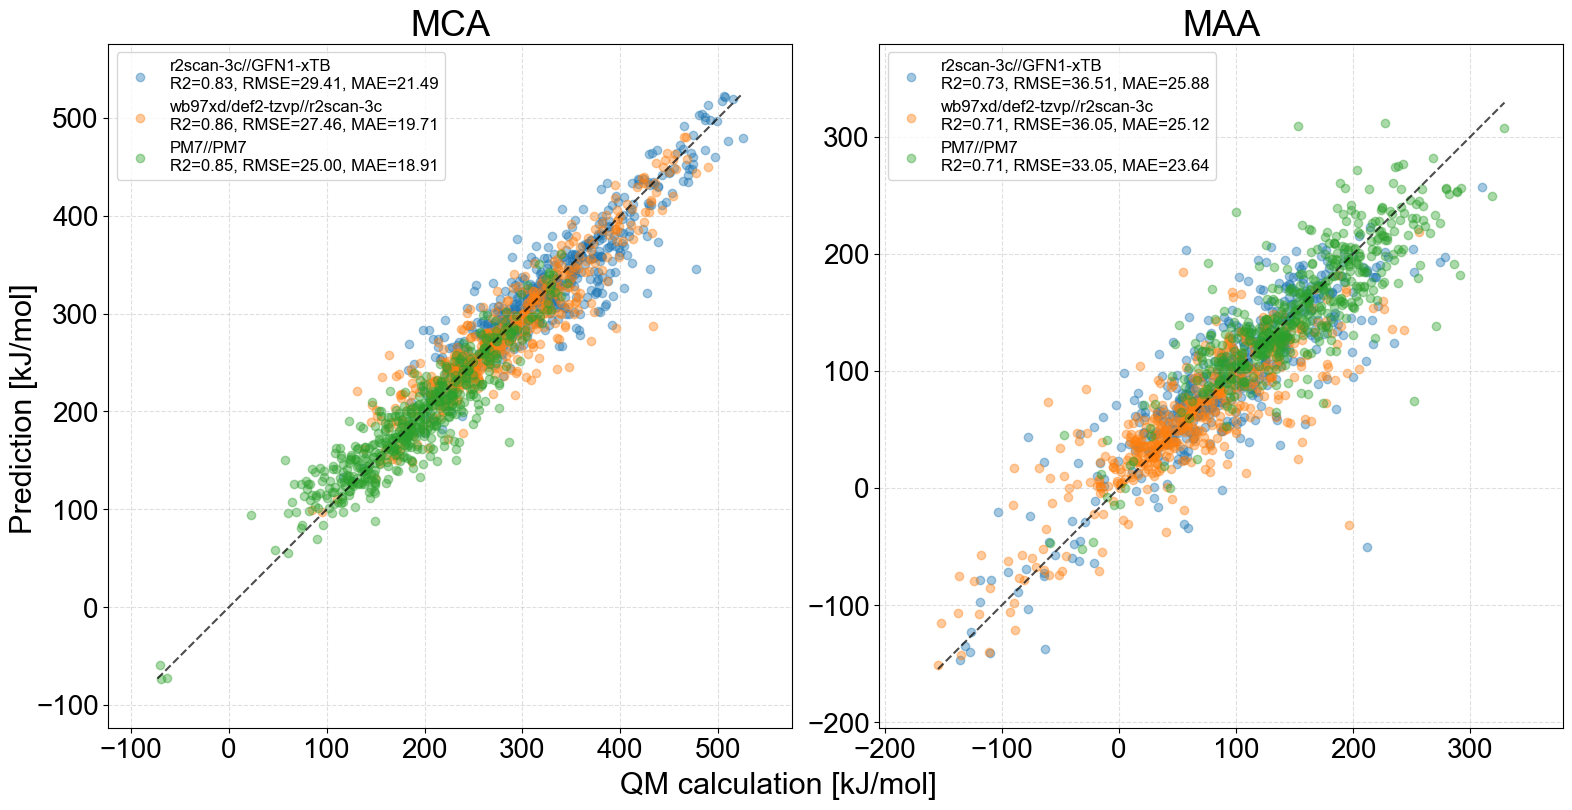

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from mod_for_analysis import load_csv

alpha = 0.4
base_font_size = 20

ticks_font_size = int(base_font_size)
title_font_size = int(base_font_size * 1.3)
label_font_size = int(base_font_size * 1.1)
legend_font_size = int(base_font_size * 0.6)

plot, axes = plt.subplots(1, 2, figsize=(16, 8))
axes = axes.flatten()

def make_parity_plot(task_name, ax, method_name):
    pred_target = 'MCA_values' if 'mca' in task_name else 'MAA_values'
    df = load_csv(f'./results/{task_name}/predictions.csv')
    df_test = df[df['split'] == 'test']
    x = df_test[pred_target]
    y = df_test['pred']

    r2 = r2_score(x, y)
    rmse = float(np.sqrt(np.mean((x - y) ** 2)))
    mae = float(mean_absolute_error(x, y))
    label = f'{method_name}\nR2={r2:.2f}, RMSE={rmse:.2f}, MAE={mae:.2f}'

    scatter = ax.scatter(x, y, alpha=alpha, label=label)

    ax.tick_params(axis='both', labelsize=ticks_font_size)
    ax.set_title(pred_target[:3], fontsize=title_font_size)

    return scatter, float(min(x.min(), y.min())), float(max(x.max(), y.max()))

def finalize_parity_plot(ax, plot_results, legend_loc='upper left'):
    lo = min(result[1] for result in plot_results)
    hi = max(result[2] for result in plot_results)
    margin = 50

    ax.plot([lo, hi], [lo, hi], '--', alpha=0.7, color='black')
    ax.set_xlim(lo - margin, hi + margin)
    ax.set_ylim(lo - margin, hi + margin)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(True, ls='--', alpha=0.4)
    ax.set_aspect('equal', adjustable='box')
    ax.legend(
        handles=[result[0] for result in plot_results],
        loc=legend_loc,
        fontsize=legend_font_size,
        frameon=True,
    )

mca_results = [
    make_parity_plot('different_metrics/mecap_mca_mmff_layer_0', axes[0], 'r2scan-3c//GFN1-xTB'),
    make_parity_plot('different_metrics/mecap_mca_orca_from_mmff_layer_0', axes[0], 'wb97xd/def2-tzvp//r2scan-3c'),
    make_parity_plot('different_metrics/mecap_mca_mopac_from_mmff_layer_0', axes[0], 'PM7//PM7'),
]
finalize_parity_plot(axes[0], mca_results, legend_loc='upper left')

maa_results = [
    make_parity_plot('different_metrics/mecap_maa_mmff_layer_0', axes[1], 'r2scan-3c//GFN1-xTB'),
    make_parity_plot('different_metrics/mecap_maa_orca_from_mmff_layer_0', axes[1], 'wb97xd/def2-tzvp//r2scan-3c'),
    make_parity_plot('different_metrics/mecap_maa_mopac_from_mmff_layer_0', axes[1], 'PM7//PM7'),
]
finalize_parity_plot(axes[1], maa_results, legend_loc='upper left')

plot.supxlabel('QM calculation [kJ/mol]', fontsize=label_font_size)
plot.supylabel('Prediction [kJ/mol]', fontsize=label_font_size)

plot.tight_layout()
plot.show()


# Case study

In [1]:
import pandas as pd

df_gth_nuc = pd.read_csv('./references/100_rxn_mechanisms/100_rxn_mechanisms_no_error_reactants_calculated_nuc.csv',index_col=0)
df_gth_elec= pd.read_csv('./references/100_rxn_mechanisms/100_rxn_mechanisms_no_error_reactants_calculated_elec.csv',index_col=0)

df_pred_mecap_nuc = pd.read_csv('./results/casestudy/100_rxn_mechanisms/mca_v2/predictions.csv')
df_pred_mecap_elec= pd.read_csv('./results/casestudy/100_rxn_mechanisms/maa_v2/predictions.csv')

df_pred_esnml_nuc = pd.read_csv('./references/100_rxn_mechanisms/100_rxn_mechanisms_no_error_reactants_predicted_nuc.csv',index_col=0)
df_pred_esnml_elec= pd.read_csv('./references/100_rxn_mechanisms/100_rxn_mechanisms_no_error_reactants_predicted_elec.csv',index_col=0)

for df in (df_gth_nuc, df_gth_elec, df_pred_mecap_nuc, df_pred_mecap_elec, df_pred_esnml_nuc, df_pred_esnml_elec,):
    site_col = 'nuc_sites' if 'nuc_sites' in df else 'elec_sites'
    name_col = 'name' if 'name' in df.columns else 'reactant_id_no_underbar'
    df['IDENTIFIER'] = [row[name_col] + '_' + str(row[site_col]) for _, row in df.iterrows()]
    if all([col in df.columns for col in ('reactant_error','product_error',)]):
        df['succeeded']  = [row['reactant_error'] == 'None' and row['product_error'] == 'None' for _, row in df.iterrows()]
    df.set_index('IDENTIFIER',drop=True,inplace=True)


In [2]:
import ast
from rdkit import Chem
from mod_for_analysis import find_additional_nuc_sites, find_additional_elec_sites

grdth_col_name = 'ESNUEL'
mecap_col_name = 'Uni-Mol-MeCAP'
esnml_col_name = 'LightGBM'

df_nuc_all  = pd.concat([df_gth_nuc.rename(columns={'MCA Value [kJ/mol]': grdth_col_name}), df_pred_mecap_nuc[['pred']].rename(columns={'pred': mecap_col_name}), df_pred_esnml_nuc[['MCA Value [kJ/mol]']].rename(columns={'MCA Value [kJ/mol]': esnml_col_name})],axis=1).fillna(False)
df_elec_all = pd.concat([df_gth_elec.rename(columns={'MAA Value [kJ/mol]': grdth_col_name}), df_pred_mecap_elec[['pred']].rename(columns={'pred': mecap_col_name}), df_pred_esnml_elec[['MAA Value [kJ/mol]']].rename(columns={'MAA Value [kJ/mol]': esnml_col_name})],axis=1).fillna(False)

# nuc_smiles_to_sites = {smi: find_additional_nuc_sites(Chem.MolFromSmiles(smi)) for smi in df_nuc_all[df_nuc_all['reactant_smi']!=False]['reactant_smi'].unique()}
# df_nuc_all['refined_nuc_names'] = df_nuc_all.apply(lambda row: nuc_smiles_to_sites[row['reactant_smi']][1][nuc_smiles_to_sites[row['reactant_smi']][0].index(row['nuc_sites'])] if row['reactant_smi'] in nuc_smiles_to_sites and row['nuc_sites'] in nuc_smiles_to_sites[row['reactant_smi']][0] else None, axis=1)

# elec_smiles_to_sites = {smi: find_additional_elec_sites(Chem.MolFromSmiles(smi)) for smi in df_elec_all[df_elec_all['reactant_smi']!=False]['reactant_smi'].unique()}
# df_elec_all['refined_elec_names'] = df_elec_all.apply(lambda row: elec_smiles_to_sites[row['reactant_smi']][1][elec_smiles_to_sites[row['reactant_smi']][0].index(row['elec_sites'])] if row['reactant_smi'] in elec_smiles_to_sites and row['elec_sites'] in elec_smiles_to_sites[row['reactant_smi']][0] else None, axis=1)

# df_nuc_no_error  = df_nuc_all[(df_nuc_all['succeeded']) & (df_nuc_all[mecap_col_name]!=False) & (df_nuc_all[esnml_col_name]!=False)].dropna(subset=['refined_nuc_names'])
# df_elec_no_error = df_elec_all[(df_elec_all['succeeded']) & (df_elec_all[mecap_col_name]!=False) & (df_elec_all[esnml_col_name]!=False)].dropna(subset=['refined_elec_names'])

df_nuc_no_error  = df_nuc_all[(df_nuc_all['succeeded']) & (df_nuc_all[mecap_col_name]!=False) & (df_nuc_all[esnml_col_name]!=False)]
df_elec_no_error = df_elec_all[(df_elec_all['succeeded']) & (df_elec_all[mecap_col_name]!=False) & (df_elec_all[esnml_col_name]!=False)]

df_rxn = pd.read_csv("./references/100_rxn_mechanisms/100_rxn_mechanisms_no_error.csv", index_col=0)

df_nuc_no_error['is_mapped_site'] = df_nuc_no_error.apply(
    lambda row: int(row['nuc_sites']) == ast.literal_eval(row['mapped_atoms'])[df_rxn.loc[int(row['rxn_id']),'sink']] if df_rxn.loc[int(row['rxn_id']),'sink'] in ast.literal_eval(row['mapped_atoms']) else False,axis=1)
df_elec_no_error['is_mapped_site'] = df_elec_no_error.apply(
    lambda row: int(row['elec_sites']) == ast.literal_eval(row['mapped_atoms'])[df_rxn.loc[int(row['rxn_id']),'source']] if df_rxn.loc[int(row['rxn_id']),'source'] in ast.literal_eval(row['mapped_atoms']) else False,axis=1)

df_nuc_no_error.rename(columns={'nuc_sites': 'Atom index'},inplace=True)
df_nuc_no_error = df_nuc_no_error.astype({'Atom index': int})

df_elec_no_error.rename(columns={'elec_sites': 'Atom index'},inplace=True)
df_elec_no_error = df_elec_no_error.astype({'Atom index': int})

is_nuc_mapped_rxn = (df_nuc_no_error.groupby('rxn_id').apply(lambda gdf: any(gdf['is_mapped_site'])))
is_elec_mapped_rxn= (df_elec_no_error.groupby('rxn_id').apply(lambda gdf: any(gdf['is_mapped_site'])))

/tmp/ipykernel_971944/2942620006.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nuc_no_error['is_mapped_site'] = df_nuc_no_error.apply(
/tmp/ipykernel_971944/2942620006.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec_no_error['is_mapped_site'] = df_elec_no_error.apply(
/tmp/ipykernel_971944/2942620006.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

In [3]:
from mod_for_analysis import calculate_kendall_correlation_by_group

df_rxn_mecap_nuc_corr  = calculate_kendall_correlation_by_group(df_nuc_no_error, 'rxn_id', grdth_col_name, mecap_col_name)
df_rxn_mecap_elec_corr = calculate_kendall_correlation_by_group(df_elec_no_error, 'rxn_id', grdth_col_name, mecap_col_name)

df_rxn_esnml_nuc_corr  = calculate_kendall_correlation_by_group(df_nuc_no_error, 'rxn_id', grdth_col_name, esnml_col_name)
df_rxn_esnml_elec_corr = calculate_kendall_correlation_by_group(df_elec_no_error, 'rxn_id', grdth_col_name, esnml_col_name)

df_rxn_mecap_nuc_corr['Type'] = 'MCA'; df_rxn_mecap_nuc_corr['ML method'] = mecap_col_name
df_rxn_mecap_elec_corr['Type'] = 'MAA'; df_rxn_mecap_elec_corr['ML method'] = mecap_col_name

df_rxn_esnml_nuc_corr['Type'] = 'MCA'; df_rxn_esnml_nuc_corr['ML method'] = esnml_col_name
df_rxn_esnml_elec_corr['Type'] = 'MAA'; df_rxn_esnml_elec_corr['ML method'] = esnml_col_name

df_rxn_to_plot = pd.concat([df_rxn_mecap_nuc_corr,df_rxn_esnml_nuc_corr,df_rxn_mecap_elec_corr,df_rxn_esnml_elec_corr]).reset_index()

Top-1 matched rate (Uni-Mol-MeCAP):
  Nucleophilic -> 0.764
  Electrophilic -> 0.678
Top-1 matched rate (ESNUEL_ML):
  Nucleophilic -> 0.674
  Electrophilic -> 0.800


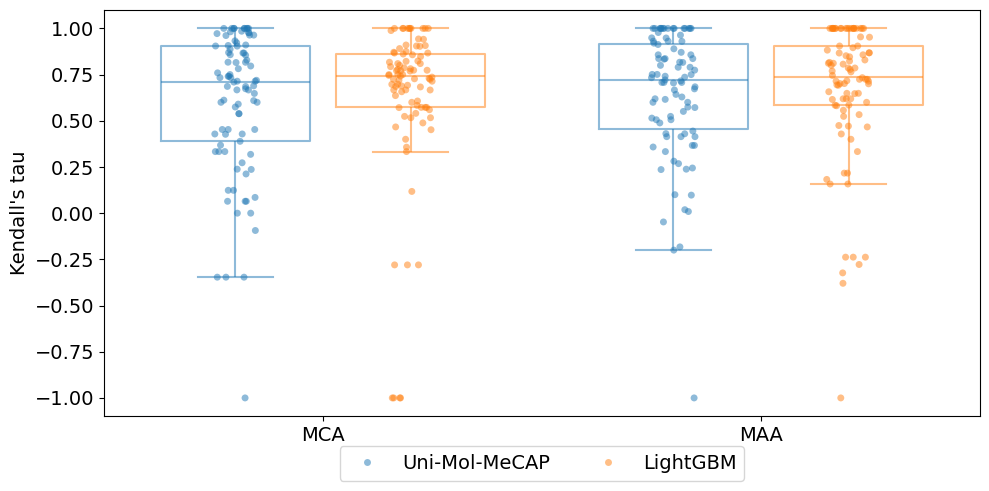

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

alpha = 0.5
base_font_size = 14

ticks_font_size = int(base_font_size)
title_font_size = int(base_font_size * 1.3)
label_font_size = int(base_font_size * 1.1)


print(f'Top-1 matched rate (Uni-Mol-MeCAP):\n'
      f'  Nucleophilic -> {len(df_rxn_mecap_nuc_corr.dropna(subset=["max_index_match"])[df_rxn_mecap_nuc_corr.dropna(subset=["max_index_match"])["max_index_match"]]) / len(df_rxn_mecap_nuc_corr.dropna(subset=["max_index_match"])):.3f}\n'
      f'  Electrophilic -> {len(df_rxn_mecap_elec_corr.dropna(subset=["max_index_match"])[df_rxn_mecap_elec_corr.dropna(subset=["max_index_match"])["max_index_match"]]) / len(df_rxn_mecap_elec_corr.dropna(subset=["max_index_match"])):.3f}')

print(f'Top-1 matched rate (ESNUEL_ML):\n'
      f'  Nucleophilic -> {len(df_rxn_esnml_nuc_corr.dropna(subset=["max_index_match"])[df_rxn_esnml_nuc_corr.dropna(subset=["max_index_match"])["max_index_match"]]) / len(df_rxn_esnml_nuc_corr.dropna(subset=["max_index_match"])):.3f}\n'
      f'  Electrophilic -> {len(df_rxn_esnml_elec_corr.dropna(subset=["max_index_match"])[df_rxn_esnml_elec_corr.dropna(subset=["max_index_match"])["max_index_match"]]) / len(df_rxn_esnml_elec_corr.dropna(subset=["max_index_match"])):.3f}')

plt.figure(figsize=(10, 5))

sns.boxplot(
      df_rxn_to_plot,
      y='tau',
      x='Type',
      hue='ML method',
      fill=False,
      gap=0.15,
      showfliers=False,
      legend=False,
      boxprops={'alpha': alpha},
      whiskerprops={'alpha': alpha},
      capprops={'alpha': alpha},
      medianprops={'alpha': alpha},
)
sns.stripplot(df_rxn_to_plot, y='tau', x='Type', hue='ML method', dodge=True, alpha=alpha, size=5)

plt.tick_params(axis='both', labelsize=ticks_font_size)
plt.xlabel('')
plt.ylabel("Kendall's tau",fontsize=ticks_font_size)
plt.title('')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=ticks_font_size)
plt.tight_layout()

In [5]:
tmp = df_rxn_to_plot[["rxn_id", "Type", "ML method", "n", "tau"]].dropna().copy()

methods = [mecap_col_name, esnml_col_name]
tmp = tmp[tmp["ML method"].isin(methods)]

wide = (
    tmp.pivot_table(
        index=["rxn_id", "Type"],
        columns="ML method",
        values=["tau", "n"],
        aggfunc="first",
    )
    .dropna(subset=[("tau", mecap_col_name), ("tau", esnml_col_name)])
    .copy()
)

wide["tau_diff"] = wide[("tau", mecap_col_name)] - wide[("tau", esnml_col_name)]

wide["n_plot"] = wide[("n", mecap_col_name)]

plot_df = wide.reset_index()

print('===MCA===')
df_mca_tau_min_max = plot_df[(plot_df["rxn_id"].isin(is_nuc_mapped_rxn[is_nuc_mapped_rxn].index)) & (plot_df['Type']=='MCA') & (plot_df['n'][mecap_col_name]>=8) & (plot_df['n'][mecap_col_name]<=12)].sort_values('tau_diff').iloc[[0,-1]]
display(df_mca_tau_min_max)

print('===MAA===')
df_maa_tau_min_max = plot_df[(plot_df["rxn_id"].isin(is_elec_mapped_rxn[is_elec_mapped_rxn].index)) & (plot_df['Type']=='MAA') & (plot_df['n'][mecap_col_name]>=8) & (plot_df['n'][mecap_col_name]<=12)].sort_values('tau_diff').iloc[[0,-1]]
display(df_maa_tau_min_max)

===MCA===


rxn_id Type        n                     tau                \
ML method             LightGBM Uni-Mol-MeCAP  LightGBM Uni-Mol-MeCAP   
82          47.0  MCA       10            10  0.847579      0.816497   
67          39.0  MCA       11            11  0.698113      0.796433   

           tau_diff n_plot  
ML method                   
82        -0.031083     10  
67         0.098320     11

===MAA===


rxn_id Type        n                     tau                \
ML method             LightGBM Uni-Mol-MeCAP  LightGBM Uni-Mol-MeCAP   
44          28.0  MAA       12            12  0.806452      0.281387   
26          18.0  MAA       10            10 -0.238095      0.414039   

           tau_diff n_plot  
ML method                   
44        -0.525064     12  
26         0.652135     10

***MCA***
===rxn_id: 47===


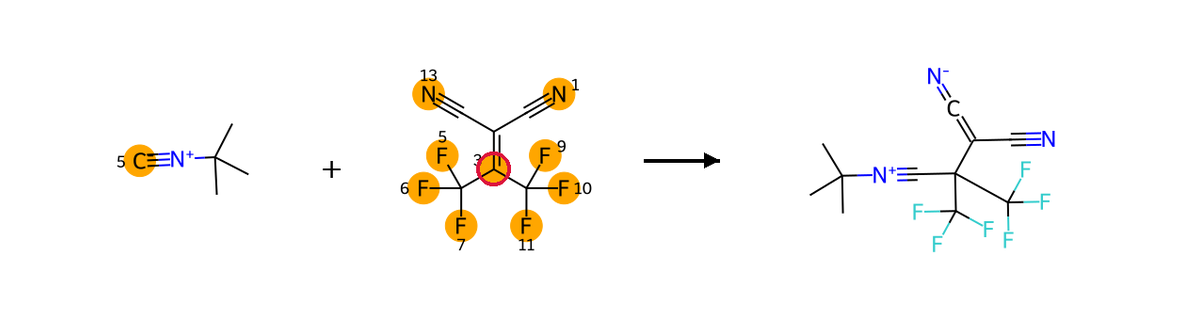

,Reactant,Atom index,ESNUEL,Uni-Mol-MeCAP,LightGBM
IDENTIFIER,,,,,
47reac0_5,0,5,485.23,464.55,444.64
47reac1_1,1,1,315.77,312.37,266.01
47reac1_13,1,13,311.47,311.77,266.01
47reac1_3,1,3,129.62,179.04,274.48
47reac1_6,1,6,95.05,64.83,125.13
47reac1_5,1,5,95.05,66.05,125.13
47reac1_7,1,7,95.05,60.36,125.13
47reac1_9,1,9,95.05,60.54,125.13
47reac1_10,1,10,95.05,64.90,125.13


===rxn_id: 39===


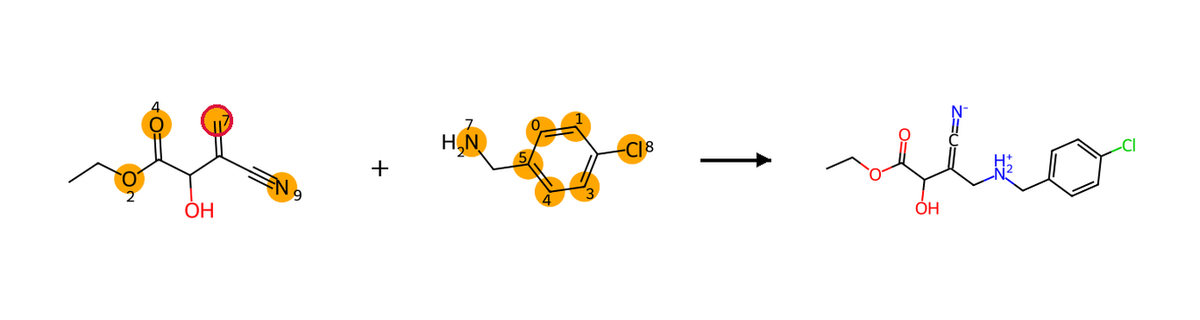

,Reactant,Atom index,ESNUEL,Uni-Mol-MeCAP,LightGBM
IDENTIFIER,,,,,
39reac0_9,0,9,343.93,348.85,354.60
39reac0_4,0,4,273.81,284.39,294.49
39reac0_7,0,7,253.42,259.18,305.11
39reac0_2,0,2,212.66,218.37,221.18
39reac1_7,1,7,486.15,479.04,483.95
39reac1_5,1,5,321.85,319.93,320.61
39reac1_0,1,0,300.35,291.42,300.29
39reac1_4,1,4,300.35,291.42,300.29
39reac1_1,1,1,298.56,293.48,293.99


*********

***MAA***
===rxn_id: 28===


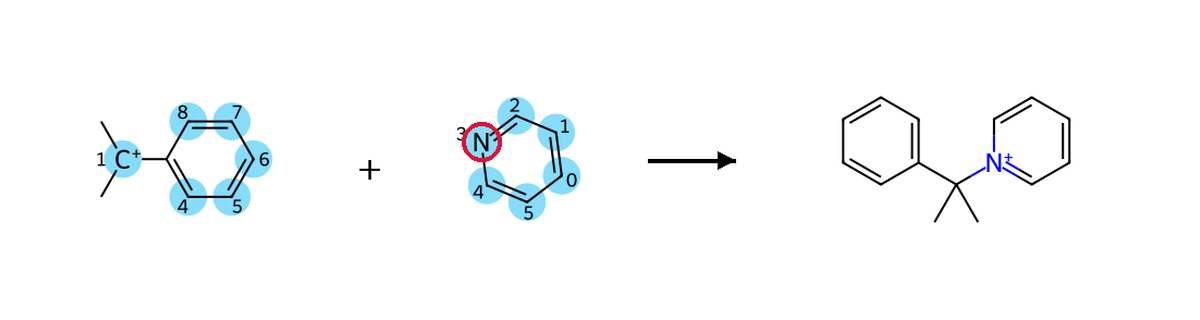

,Reactant,Atom index,ESNUEL,Uni-Mol-MeCAP,LightGBM
IDENTIFIER,,,,,
28reac0_1,0,1,471.23,108.76,278.31
28reac0_6,0,6,352.71,100.11,232.85
28reac0_4,0,4,344.42,100.90,194.65
28reac0_8,0,8,344.42,100.36,194.65
28reac0_5,0,5,122.71,68.88,209.51
28reac0_7,0,7,122.71,69.04,209.51
28reac1_0,1,0,131.74,136.32,131.95
28reac1_2,1,2,117.58,125.38,119.41
28reac1_4,1,4,117.58,125.38,119.41


===rxn_id: 18===


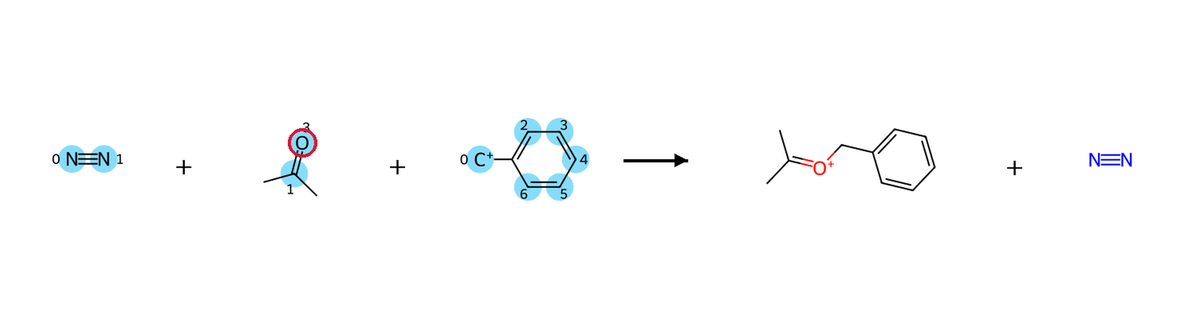

,Reactant,Atom index,ESNUEL,Uni-Mol-MeCAP,LightGBM
IDENTIFIER,,,,,
18reac0_0,0,0,-79.19,99.83,319.09
18reac0_1,0,1,-79.19,99.83,319.09
18reac1_1,1,1,137.38,144.76,163.74
18reac1_3,1,3,-69.95,-54.68,-53.30
18reac2_0,2,0,551.47,143.18,267.46
18reac2_4,2,4,426.07,108.25,217.00
18reac2_2,2,2,410.52,114.58,236.34
18reac2_6,2,6,410.52,114.58,236.34
18reac2_3,2,3,124.17,77.93,250.74


*********



In [9]:
import ast
from mod_for_analysis import visualize_reaction_smiles_highlight

pd.options.display.float_format = '{:.2f}'.format

print('***MCA***')
df_nuc_no_error['Reactant'] = df_nuc_no_error['reactant_id_no_underbar'].apply(lambda s: s.split('reac')[-1])

for index, row in df_rxn.loc[df_mca_tau_min_max['rxn_id'].astype(int).to_list()].iterrows():
    print(f'===rxn_id: {index}===')
    nuc_vals = df_nuc_no_error[df_nuc_no_error['rxn_id']==index]
    num_rcts = max([int(s.split('reac')[-1]) for s in nuc_vals['reactant_id_no_underbar'].unique()]) + 1    # Considering no-MCA-assigned reactants
    nuc_maps = [[] for _ in range(num_rcts)]
    rxn_sites= [[] for _ in range(num_rcts)]
    sink     = row['sink']
    source   = row['source']
    for s in nuc_vals['reactant_id_no_underbar'].unique():
        nsite = nuc_vals[nuc_vals['reactant_id_no_underbar']==s]['mapped_atoms'].unique()
        assert len(nsite) == 1
        nsite = ast.literal_eval(nsite[0])
        if sink in nsite:
            rxn_sites[int(s.split('reac')[-1])].append(nsite[sink])
        # if source in nsite:
        #     rxn_sites[int(s.split('reac')[-1])].append(nsite[source])
    for _, val in nuc_vals.iterrows():
        rct_ord = int(val['reactant_id_no_underbar'].split('reac')[-1])
        rct_idx = int(val['Atom index'])
        map_idx = ast.literal_eval(val['mapped_atoms'])
        nuc_maps[rct_ord].append(rct_idx)
    display(visualize_reaction_smiles_highlight(
        reaction_smiles=row['SMIRKS'].split()[0],
        reaction_center_atom_indices=rxn_sites,
        mca_atom_indices=nuc_maps,
        fixed_bond_length=40,
        output_size=(1200,320),
    ))
    display(df_nuc_no_error[df_nuc_no_error['rxn_id']==index][['Reactant','Atom index',grdth_col_name, mecap_col_name, esnml_col_name]])
print('*********\n')

print('***MAA***')
df_elec_no_error['Reactant'] = df_elec_no_error['reactant_id_no_underbar'].apply(lambda s: s.split('reac')[-1])
for index, row in df_rxn.loc[df_maa_tau_min_max['rxn_id'].astype(int).to_list()].iterrows():
    print(f'===rxn_id: {index}===')
    elec_vals = df_elec_no_error[df_elec_no_error['rxn_id']==index]
    num_rcts  = max([int(s.split('reac')[-1]) for s in elec_vals['reactant_id_no_underbar'].unique()]) + 1    # Considering no-MCA-assigned reactants
    elec_maps = [[] for _ in range(num_rcts)]
    rxn_sites = [[] for _ in range(num_rcts)]
    sink      = row['sink']
    source    = row['source']
    for s in elec_vals['reactant_id_no_underbar'].unique():
        esite = elec_vals[elec_vals['reactant_id_no_underbar']==s]['mapped_atoms'].unique()
        assert len(esite) == 1
        esite = ast.literal_eval(esite[0])
        # if sink in esite:
        #     rxn_sites[int(s.split('reac')[-1])].append(esite[sink])
        if source in esite:
            rxn_sites[int(s.split('reac')[-1])].append(esite[source])
    for _, val in elec_vals.iterrows():
        rct_ord = int(val['reactant_id_no_underbar'].split('reac')[-1])
        rct_idx = int(val['Atom index'])
        map_idx = ast.literal_eval(val['mapped_atoms'])
        elec_maps[rct_ord].append(rct_idx)
    display(visualize_reaction_smiles_highlight(
        reaction_smiles=row['SMIRKS'].split()[0],
        reaction_center_atom_indices=rxn_sites,
        maa_atom_indices=elec_maps,
        fixed_bond_length=40,
        output_size=(1200,320),
    ))
    display(df_elec_no_error[df_elec_no_error['rxn_id']==index][['Reactant','Atom index',grdth_col_name, mecap_col_name, esnml_col_name]])
print('*********\n')
